#Arabic multi-domain aspect-based sentiment analysis system using the A-MASA dataset

**Affiliation:** School of Information Technology and Computer Science (ITCS), Nile University (NU), Giza, Egypt

**Course Code & Lecture section:** AIS411: Natural Language Processing-2026SPRG-LECT-01

**Lab Section:** 01A

**Supervised by:** Dr.Walaa Medhat / Eng.Yomna Eid

*   Hossam Alghazaly → 221001672
*   Alia Mostafa → 221001994
*   Yomna Khairy → 221001896
*   Moaz Elkhashab → 221001732
*   Hassan Sabry → 221001707





## Libraries and assets

In [44]:
# ── Google Colab ─────────────────────────────────────────────────
# Run this block if you are on Google Colab
import sys
if 'google.colab' in sys.modules:
    !pip install pyarabic -q
    !pip install nltk -q
    !pip install camel-tools -q
    !pip install transformers -q
    !pip install emoji -q
    !pip install wordcloud -q
    !pip install emosent-py
    print("✓ Colab packages installed")

# ── Local Jupyter ─────────────────────────────────────────────────
# Run this block if you are on a local Jupyter environment
# (Uncomment and run once, then comment out again)
# import subprocess, sys
# packages = [
#     "pyarabic", "nltk", "camel-tools", "transformers",
#     "emoji", "wordcloud", "plotly", "spacy"
# ]
# for pkg in packages:
#     subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])
# print("✓ Local packages installed")


✓ Colab packages installed


In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import nltk
from nltk.corpus import stopwords
import pyarabic.araby as araby
from camel_tools.dialectid import DialectIdentifier
from transformers import pipeline
import spacy
import unicodedata
import emoji
from collections import Counter
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer, WordNetLemmatizer
import string
import warnings
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from collections import Counter
from wordcloud import WordCloud
from emosent import get_emoji_sentiment_rank

In [46]:
warnings.filterwarnings('ignore')
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('punkt', quiet=True)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_style("whitegrid")

## Exploratory Data Analytics


Procedures:
1.   Dataset Preview
2.   Dataset Dimensions
3.   Null Values Count
4.   Duplicated Values Count
5.   Most Used Aspects
6.   Number of diacritics
7.   Stop Words Frequency
8.   Check for mixed scripts (Arabic + Latin + numbers)
9.   Emoji & emoticon density
10.  Dialect Detection





### Tourism-Domain Dataset

In [47]:
ATTdf=pd.read_csv("/content/ATT.csv")

In [ ]:
ATTdf.head(10)

,Column1,Sentences,Aspects,Sentences Sentiment,Aspects Sentiment
0,0,\nنصحوني بتجربة حمام الكبريت. يمكنكم الدخول مع...,الحمام، العاملات، الإنجليزية,1,"1, 1, -1"
1,1,قلعة ساحرة \r\nمنظر خلاب للمدينة من أعلى القلع...,قلعة، منظر، حديقة نباتات، مجرى مائي,1,"1, 1, 1, 1"
2,2,تبليسي جورجيا\nمن أجمل المدن التي زرتها في حيا...,تبليسي جورجيا، شعبها، الحياة,1,"1, 1, 1"
3,3,جولة على المدينة القديمة تبليسي شاردن \nممتعة ...,المدينة القديمة تبليسي، الجولة، جلساتها، تلفري...,1,"1,1,1,1,1,1"
4,4,احلي اجازه لمحبي الطبيعه \r\nالمناظر الخلابه ا...,اجازه، المناظر، الاجواء، ميزه,1,"1,1,1,0"
5,5,الصعود لقمة مطل تبليسي \r\nالصعود لقمة المرتفع...,الصعود، قطار، بمنظر,1,"1,1,1"
6,7,جميل جدا \r\nيعرض لك وبصورة مبسطة تاريخ وتقالي...,بصورة، مناظر، الغابات,1,"1,0,1"
7,8,مدينة جميلة تستحق الزيارة \r\nتبليسي عاصمة جور...,مدينة، تبليسي، سكانها، الأسعار، المعالم، قلعة ...,1,"1,0,0,1,1,1,1,1,0,1,0,1,1"
8,9,اللهم ارزقنا الجنة \r\nمنطقه رائعه وجميلة جدا ...,منطقه، الضباب، الذهاب، الطريق، محلات,1,"1,0,1,1,0"
9,10,ممتازه \r\nجو روعه ولا بالخيال وتزدحم اثناء ال...,جو,1,1


In [ ]:
ATTdf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1503 entries, 0 to 1502
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Column1              1500 non-null   object
 1   Sentences            1503 non-null   object
 2   Aspects              1490 non-null   object
 3   Sentences Sentiment  1501 non-null   object
 4   Aspects Sentiment    1489 non-null   object
dtypes: object(5)
memory usage: 58.8+ KB


In [29]:
ATTdf.columns

Index(['Sentences', 'Aspects', 'Sentences Sentiment', 'Aspects Sentiment',
       'dialect'],
      dtype='object')

In [ ]:
ATTdf.shape

(1503, 5)

In [ ]:
ATTdf.isnull().sum()

,0
Column1,3
Sentences,0
Aspects,13
Sentences Sentiment,2
Aspects Sentiment,14


In [ ]:
ATTdf.duplicated().sum()

np.int64(0)

In [ ]:
all_aspects = pd.Series(dtype=object)

for df in [ATTdf]:
    if 'Aspects' in df.columns:
        # Fill NaN with empty string to avoid errors during string operations
        # Then split the string by comma and space, expand into a list of aspects
        aspects_list = df['Aspects'].dropna().astype(str).str.split(',\s*').explode()
        all_aspects = pd.concat([all_aspects, aspects_list])

# Remove any empty strings that might have resulted from splitting
all_aspects = all_aspects[all_aspects != '']

# Count the occurrences of each aspect
aspect_counts = all_aspects.value_counts()

# Get the most duplicated aspects (top 10 for demonstration)
most_duplicated_aspects = aspect_counts.head(10)

print("Most duplicated aspects across all datasets:")
print(most_duplicated_aspects)


Most duplicated aspects across all datasets:
مكان            32
المكان           9
مكان، المكان     6
مترو دبي         4
الاماكن          4
معلم             3
منظر             3
المتحف           3
نافوره           3
متحف             3
Name: count, dtype: int64


<>:7: SyntaxWarning: invalid escape sequence '\s'
<>:7: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_7359/2523521368.py:7: SyntaxWarning: invalid escape sequence '\s'
  aspects_list = df['Aspects'].dropna().astype(str).str.split(',\s*').explode()


In [ ]:
def count_diacritics_pyarabic(text):
    if pd.isna(text):
        return 0
    original_text = str(text)
    text_without_diacritics = araby.strip_tashkeel(original_text)
    # The number of diacritics is the difference in length if we only consider non-space characters
    return sum(1 for char in original_text if araby.is_tashkeel(char))

# Applying the function to the 'Sentences' column of ATTdf
ATTdf['Diacritic_Count_pyarabic'] = ATTdf['Sentences'].apply(count_diacritics_pyarabic)

total_diacritics_pyarabic = ATTdf['Diacritic_Count_pyarabic'].sum()

print(f"Total number of diacritics in the 'Sentences' column of ATTdf: {total_diacritics_pyarabic}")

Total number of diacritics in the 'Sentences' column of ATTdf: 195


In [53]:
nlp = spacy.blank("ar")

def analyze_scripts(text):
    doc = nlp(str(text))

    has_arabic  = any(unicodedata.name(c, '').startswith('ARABIC')
                      for t in doc for c in t.text if t.is_alpha)
    has_latin   = any(c.isascii() and c.isalpha()
                      for t in doc for c in t.text)
    has_numbers = any(t.like_num or t.is_digit for t in doc)

    scripts = [s for s, f in [('Arabic', has_arabic),
                                ('Latin',  has_latin),
                                ('Numeric', has_numbers)] if f]

    return pd.Series({
        'has_arabic':  has_arabic,
        'has_latin':   has_latin,
        'has_numbers': has_numbers,
        'is_mixed':    len(scripts) > 1,
        'script_type': ('Mixed: ' + ' + '.join(scripts)
                        if len(scripts) > 1
                        else (scripts[0] + ' only' if scripts else 'Other'))
    })

In [54]:
script_df = ATTdf['Sentences'].apply(analyze_scripts)
ATTdf = pd.concat([ATTdf, script_df], axis=1)

print(ATTdf['script_type'].value_counts())
print(ATTdf[ATTdf['is_mixed']][['Sentences', 'script_type']].head(10))

script_type
Arabic only                        1234
Mixed: Arabic + Numeric             217
Mixed: Arabic + Latin                38
Mixed: Arabic + Latin + Numeric      14
Name: count, dtype: int64
                                            Sentences  \
0   \nنصحوني بتجربة حمام الكبريت. يمكنكم الدخول مع...   
8   اللهم ارزقنا الجنة \r\nمنطقه رائعه وجميلة جدا ...   
15  رحلة ممتعة \nالمكان قمة جبل بيلاتوس وهو على ار...   
17  رائع جدا ، اﻻطﻻله على المدينه رائعه \r\nيمكن ا...   
19  ممتع \r\nحبيت الاجواء في الشارع والشوارع الي ح...   
25  ممتعه بجد \r\nهي عباره عن ٥ او ٦ مناطق للتنزه ...   
26  العوده للطفولة \r\nيعطيك المتحف نوع من الابتسا...   
28  مكان رائع \nيوجد عدة شلالات وكلها رائعه لكن ال...   
29  عادي \r\nلو ماكان من ضمن الجدول تبع التور ماكن...   
31  ممتعه للكبار والصغار :) \r\nحديقة او ارض المجس...   

                        script_type  
0           Mixed: Arabic + Numeric  
8           Mixed: Arabic + Numeric  
15          Mixed: Arabic + Numeric  
17  Mixed: Arabic + La

In [ ]:
ATTdf_preds

[{'label': 'Tunisia', 'score': 0.29683515429496765},
 {'label': 'Syria', 'score': 0.40870094299316406},
 {'label': 'Syria', 'score': 0.28070661425590515},
 {'label': 'Syria', 'score': 0.24447579681873322},
 {'label': 'Syria', 'score': 0.3027735948562622},
 {'label': 'Oman', 'score': 0.7441626787185669},
 {'label': 'Syria', 'score': 0.34119006991386414},
 {'label': 'Tunisia', 'score': 0.35329291224479675},
 {'label': 'Syria', 'score': 0.3683878779411316},
 {'label': 'Saudi_Arabia', 'score': 0.37752804160118103},
 {'label': 'Tunisia', 'score': 0.5609644055366516},
 {'label': 'Tunisia', 'score': 0.2565416395664215},
 {'label': 'Oman', 'score': 0.48327499628067017},
 {'label': 'Syria', 'score': 0.3567890226840973},
 {'label': 'Syria', 'score': 0.3598882853984833},
 {'label': 'Yemen', 'score': 0.4348545968532562},
 {'label': 'Saudi_Arabia', 'score': 0.4014360010623932},
 {'label': 'Saudi_Arabia', 'score': 0.43761542439460754},
 {'label': 'Libya', 'score': 0.5893225073814392},
 {'label': 'Sa

In [49]:
EMOTICON_RE = re.compile(r"""
    # Western emoticons
    [:;=8][\-o\*\']?[\)\]\(\[dDpP/\:\}\{@\|\\]   |  # :) ;) :D :(
    [\)\]\(\[dDpP/\:\}\{@\|\\][\-o\*\']?[:;=8]   |  # reverse )):
    <3|_\<|\*_\*|\._\.           |  # Japanese style
    owo|uwu|TwT|QwQ|:v                              # internet style
""", re.VERBOSE | re.IGNORECASE)


def analyze_emoji(text):
    text = str(text)
    total_chars = max(len(text), 1)

    # ── Unicode emojis ────────────────────────────────────
    emoji_list   = [e['emoji'] for e in emoji.emoji_list(text)]
    emoji_count  = len(emoji_list)

    # ── Text emoticons ────────────────────────────────────
    emoticon_list  = EMOTICON_RE.findall(text)
    emoticon_count = len(emoticon_list)

    total = emoji_count + emoticon_count

    return pd.Series({
        'emoji_count':      emoji_count,
        'emoticon_count':   emoticon_count,
        'has_emoji':        emoji_count > 0,
        'has_emoticon':     emoticon_count > 0,
        'emoji_list':       emoji_list,
        'emoticon_list':    emoticon_list,
    })

In [50]:
emoji_df = ATTdf['Sentences'].apply(analyze_emoji)
ATTdf    = pd.concat([ATTdf, emoji_df], axis=1)

# ── Summary ───────────────────────────────────────────────
print(f"Sentences with emojis    : {ATTdf['has_emoji'].sum():,} ({ATTdf['has_emoji'].mean()*100:.1f}%)")
print(f"Sentences with emoticons : {ATTdf['has_emoticon'].sum():,} ({ATTdf['has_emoticon'].mean()*100:.1f}%)")

# ── Most frequent emojis ──────────────────────────────────
all_emojis = [e for sublist in ATTdf['emoji_list'] for e in sublist]
print("\n=== Top 15 emojis ===")
print(pd.Series(Counter(all_emojis)).sort_values(ascending=False).head(15))

# ── Most frequent emoticons ───────────────────────────────
all_emoticons = [e for sublist in ATTdf['emoticon_list'] for e in sublist]
print("\n=== Top 15 emoticons ===")
print(pd.Series(Counter(all_emoticons)).sort_values(ascending=False).head(15))

Sentences with emojis    : 3 (0.2%)
Sentences with emoticons : 15 (1.0%)

=== Top 15 emojis ===
👍     2
☁️    1
☔     1
😍     1
dtype: int64

=== Top 15 emoticons ===
:)    17
:(     3
p:     1
(:     1
:/     1
dtype: int64


In [55]:
ATTdf.head(10)

,Column1,Sentences,Aspects,Sentences Sentiment,Aspects Sentiment,dialect,emoji_count,emoticon_count,has_emoji,has_emoticon,emoji_list,emoticon_list,has_arabic,has_latin,has_numbers,is_mixed,script_type
0,0,\nنصحوني بتجربة حمام الكبريت. يمكنكم الدخول مع...,الحمام، العاملات، الإنجليزية,1,"1, 1, -1",Tunisia,0,0,False,False,[],[],True,False,True,True,Mixed: Arabic + Numeric
1,1,قلعة ساحرة \r\nمنظر خلاب للمدينة من أعلى القلع...,قلعة، منظر، حديقة نباتات، مجرى مائي,1,"1, 1, 1, 1",Syria,0,0,False,False,[],[],True,False,False,False,Arabic only
2,2,تبليسي جورجيا\nمن أجمل المدن التي زرتها في حيا...,تبليسي جورجيا، شعبها، الحياة,1,"1, 1, 1",Syria,0,0,False,False,[],[],True,False,False,False,Arabic only
3,3,جولة على المدينة القديمة تبليسي شاردن \nممتعة ...,المدينة القديمة تبليسي، الجولة، جلساتها، تلفري...,1,"1,1,1,1,1,1",Syria,0,0,False,False,[],[],True,False,False,False,Arabic only
4,4,احلي اجازه لمحبي الطبيعه \r\nالمناظر الخلابه ا...,اجازه، المناظر، الاجواء، ميزه,1,"1,1,1,0",Syria,0,0,False,False,[],[],True,False,False,False,Arabic only
5,5,الصعود لقمة مطل تبليسي \r\nالصعود لقمة المرتفع...,الصعود، قطار، بمنظر,1,"1,1,1",Oman,0,0,False,False,[],[],True,False,False,False,Arabic only
6,7,جميل جدا \r\nيعرض لك وبصورة مبسطة تاريخ وتقالي...,بصورة، مناظر، الغابات,1,"1,0,1",Syria,0,0,False,False,[],[],True,False,False,False,Arabic only
7,8,مدينة جميلة تستحق الزيارة \r\nتبليسي عاصمة جور...,مدينة، تبليسي، سكانها، الأسعار، المعالم، قلعة ...,1,"1,0,0,1,1,1,1,1,0,1,0,1,1",Tunisia,0,0,False,False,[],[],True,False,False,False,Arabic only
8,9,اللهم ارزقنا الجنة \r\nمنطقه رائعه وجميلة جدا ...,منطقه، الضباب، الذهاب، الطريق، محلات,1,"1,0,1,1,0",Syria,0,0,False,False,[],[],True,False,True,True,Mixed: Arabic + Numeric
9,10,ممتازه \r\nجو روعه ولا بالخيال وتزدحم اثناء ال...,جو,1,1,Saudi_Arabia,0,0,False,False,[],[],True,False,False,False,Arabic only


### Movies-Domain Dataset

In [ ]:
MOVdf=pd.read_csv("/content/MOV.csv")

In [ ]:
MOVdf.head(10)

,Sentences,Sentence Sentiment,Aspects,Aspects Sentiment
0,ما بين عائلة زيزي و ميكي يعتصر مصر الالم من من...,1.0,فطين عبدالوهاب،سعاد حسني،فؤاد المهندس،احمد رمز...,"1, 1, 1, 1,1"
1,أما في فيلم عائلة ميكي 2010 و الذى اعتمد على ...,NaN,الأحلام،الأزمات،عرض,"-1,-1,1"
2,المخرج اكرم فريد ينجو أخيرا من قبضة السبكي و ا...,NaN,طاقة فنية،الأداء،أداء,"1,1,1"
3,سامحكم الله سامحكم الله الفيلم لا يعبر إطلاقاً...,-1.0,الفنون,1
4,المحتل الأمين على مدار التاريخ السينمائى الامي...,0.0,المحتل،صورة,"1,-1"
5,القاصرات ومعنى جديد للفيلم المصري معنى جديد لل...,1.0,حرفية,1
6,وصمة في تاريخ سولاف آخر أيام الحب،عنوان لمسلسل...,-1.0,عمل،أعمال،مسلسل,"1,1,-1"
7,البريء والتنفيس عن الكبت السياسي يعتبر فيلم ال...,1.0,دليل,1
8,عاطف سالم وتجربة الواقعية قد يرى البعض المخرج ...,1.0,افلام،مستوي,"1,1"
9,رأفت الميهي وفكرة المساواة دائما ماتلهمنا المش...,1.0,شجاعة،معالجة سينمائية,"1,1"


In [ ]:
MOVdf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 499 entries, 0 to 498
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Sentences           499 non-null    object 
 1   Sentence Sentiment  486 non-null    float64
 2   Aspects             466 non-null    object 
 3   Aspects Sentiment   465 non-null    object 
dtypes: float64(1), object(3)
memory usage: 15.7+ KB


In [30]:
MOVdf.columns

Index(['Sentences', 'Sentence Sentiment', 'Aspects', 'Aspects Sentiment',
       'dialect'],
      dtype='object')

In [ ]:
MOVdf.shape

(499, 4)

In [ ]:
MOVdf.isnull().sum()

,0
Sentences,0
Sentence Sentiment,13
Aspects,33
Aspects Sentiment,34


In [ ]:
MOVdf.duplicated().sum()

np.int64(0)

In [ ]:
all_aspects = pd.Series(dtype=object)

for df in [MOVdf]:
    if 'Aspects' in df.columns:
        # Fill NaN with empty string to avoid errors during string operations
        # Then split the string by comma and space, expand into a list of aspects
        aspects_list = df['Aspects'].dropna().astype(str).str.split(',\s*').explode()
        all_aspects = pd.concat([all_aspects, aspects_list])

# Remove any empty strings that might have resulted from splitting
all_aspects = all_aspects[all_aspects != '']

# Count the occurrences of each aspect
aspect_counts = all_aspects.value_counts()

# Get the most duplicated aspects (top 10 for demonstration)
most_duplicated_aspects = aspect_counts.head(10)

print("Most duplicated aspects across all datasets:")
print(most_duplicated_aspects)


Most duplicated aspects across all datasets:
فيلم       12
الفيلم      8
عمل         4
قصة         4
مخرج        3
صورة        3
شكل         3
المشاهد     3
القصة       3
أفلام       3
Name: count, dtype: int64


<>:7: SyntaxWarning: invalid escape sequence '\s'
<>:7: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_7359/2037397376.py:7: SyntaxWarning: invalid escape sequence '\s'
  aspects_list = df['Aspects'].dropna().astype(str).str.split(',\s*').explode()


In [ ]:
def count_diacritics_pyarabic(text):
    if pd.isna(text):
        return 0
    original_text = str(text)
    text_without_diacritics = araby.strip_tashkeel(original_text)
    # The number of diacritics is the difference in length if we only consider non-space characters
    return sum(1 for char in original_text if araby.is_tashkeel(char))

MOVdf['Diacritic_Count_pyarabic'] = MOVdf['Sentences'].apply(count_diacritics_pyarabic)

total_diacritics_pyarabic = MOVdf['Diacritic_Count_pyarabic'].sum()

print(f"Total number of diacritics in the 'Sentences' column of MOVdf: {total_diacritics_pyarabic}")

Total number of diacritics in the 'Sentences' column of MOVdf: 412


In [56]:
script_df = MOVdf['Sentences'].apply(analyze_scripts)
MOVdf = pd.concat([MOVdf, script_df], axis=1)

print(MOVdf['script_type'].value_counts())
print(MOVdf[MOVdf['is_mixed']][['Sentences', 'script_type']].head(10))

script_type
Arabic only                        297
Mixed: Arabic + Numeric            186
Mixed: Arabic + Latin                9
Mixed: Arabic + Latin + Numeric      7
Name: count, dtype: int64
                                            Sentences              script_type
0   ما بين عائلة زيزي و ميكي يعتصر مصر الالم من من...  Mixed: Arabic + Numeric
1    أما في فيلم عائلة ميكي 2010 و الذى اعتمد على ...  Mixed: Arabic + Numeric
3   سامحكم الله سامحكم الله الفيلم لا يعبر إطلاقاً...  Mixed: Arabic + Numeric
18  انطلاقة لم تكتمل .. الفشل تصنعه الدعاية .. و م...  Mixed: Arabic + Numeric
22  انور وجدي وحدوتة قبل النوم حدوته بسيطة افتعاله...  Mixed: Arabic + Numeric
25  ذات يوم والوقوع فى فخ اﻹستسهال لا أدرى السبب ا...    Mixed: Arabic + Latin
27  وجه نظري في فيلم سيما علي بابا بالنسبه لي هذه ...  Mixed: Arabic + Numeric
28  مفهوم الشرف والاخلاق بشكل عام اشرف فهمي مخرج م...  Mixed: Arabic + Numeric
30  ابواب الخوف واول دراما رعب عربية بعيدا عن أن م...  Mixed: Arabic + Numeric
33  عاطف الطيب و

In [57]:
emoji_df = MOVdf['Sentences'].apply(analyze_emoji)
MOVdf    = pd.concat([MOVdf, emoji_df], axis=1)

# ── Summary ───────────────────────────────────────────────
print(f"Sentences with emojis    : {MOVdf['has_emoji'].sum():,} ({MOVdf['has_emoji'].mean()*100:.1f}%)")
print(f"Sentences with emoticons : {MOVdf['has_emoticon'].sum():,} ({MOVdf['has_emoticon'].mean()*100:.1f}%)")

# ── Most frequent emojis ──────────────────────────────────
all_emojis = [e for sublist in MOVdf['emoji_list'] for e in sublist]
print("\n=== Top 15 emojis ===")
print(pd.Series(Counter(all_emojis)).sort_values(ascending=False).head(15))

# ── Most frequent emoticons ───────────────────────────────
all_emoticons = [e for sublist in MOVdf['emoticon_list'] for e in sublist]
print("\n=== Top 15 emoticons ===")
print(pd.Series(Counter(all_emoticons)).sort_values(ascending=False).head(15))

Sentences with emojis    : 0 (0.0%)
Sentences with emoticons : 8 (1.6%)

=== Top 15 emojis ===
Series([], dtype: object)

=== Top 15 emoticons ===
:)    7
:/    1
8\    1
8/    1
dtype: int64


In [59]:
MOVdf.head(10)

,Sentences,Sentence Sentiment,Aspects,Aspects Sentiment,dialect,has_arabic,has_latin,has_numbers,is_mixed,script_type,emoji_count,emoticon_count,has_emoji,has_emoticon,emoji_list,emoticon_list
0,ما بين عائلة زيزي و ميكي يعتصر مصر الالم من من...,1.0,فطين عبدالوهاب،سعاد حسني،فؤاد المهندس،احمد رمز...,"1, 1, 1, 1,1",Egypt,True,False,True,True,Mixed: Arabic + Numeric,0,0,False,False,[],[]
1,أما في فيلم عائلة ميكي 2010 و الذى اعتمد على ...,NaN,الأحلام،الأزمات،عرض,"-1,-1,1",Egypt,True,False,True,True,Mixed: Arabic + Numeric,0,0,False,False,[],[]
2,المخرج اكرم فريد ينجو أخيرا من قبضة السبكي و ا...,NaN,طاقة فنية،الأداء،أداء,"1,1,1",Tunisia,True,False,False,False,Arabic only,0,0,False,False,[],[]
3,سامحكم الله سامحكم الله الفيلم لا يعبر إطلاقاً...,-1.0,الفنون,1,Egypt,True,False,True,True,Mixed: Arabic + Numeric,0,0,False,False,[],[]
4,المحتل الأمين على مدار التاريخ السينمائى الامي...,0.0,المحتل،صورة,"1,-1",Egypt,True,False,False,False,Arabic only,0,0,False,False,[],[]
5,القاصرات ومعنى جديد للفيلم المصري معنى جديد لل...,1.0,حرفية,1,Tunisia,True,False,False,False,Arabic only,0,0,False,False,[],[]
6,وصمة في تاريخ سولاف آخر أيام الحب،عنوان لمسلسل...,-1.0,عمل،أعمال،مسلسل,"1,1,-1",Morocco,True,False,False,False,Arabic only,0,0,False,False,[],[]
7,البريء والتنفيس عن الكبت السياسي يعتبر فيلم ال...,1.0,دليل,1,Egypt,True,False,False,False,Arabic only,0,0,False,False,[],[]
8,عاطف سالم وتجربة الواقعية قد يرى البعض المخرج ...,1.0,افلام،مستوي,"1,1",Egypt,True,False,False,False,Arabic only,0,0,False,False,[],[]
9,رأفت الميهي وفكرة المساواة دائما ماتلهمنا المش...,1.0,شجاعة،معالجة سينمائية,"1,1",Jordan,True,False,False,False,Arabic only,0,0,False,False,[],[]


### Products-Domain Dataset

In [ ]:
PRODdf=pd.read_csv("/content/PROD.csv")

In [ ]:
PRODdf.head(10)

,Sentences,Aspects,Sentence Sentiment,Aspects Sentiment,Stopword_Count
0,ممتازة بصراحه مريحة خاصتا في الخرجات الي من غي...,NaN,1.0,NaN,3
1,المنتج عملي,المنتج,1.0,1,0
2,جيد نوع,نوع,0.0,1,0
3,اشتريت السلعه ودفعت ثمنها من الماستر كارد وتم ...,NaN,-1.0,NaN,2
4,شنطة جميلة وأنيقة وسعرها مناسب جدا,شنطة،سعر,-1.0,"1, 1",0
5,الشنطة حلوه,الشنطة,1.0,1,0
6,هذا السرير (أو المحجر كما يسمى) ممتاز ... نوم ...,السرير،محجر,1.0,"1, 1",5
7,لعبة مفيده,لعبة,1.0,1,0
8,مرااا حلوة احلى شيء انها تجمع اكتر من شيء بمكا...,السرير،الطريقة,1.0,"1, 1",5
9,هذه السلعه ممتازة جدا وفريدة من نوعها,السلعه,1.0,1,2


In [ ]:
PRODdf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1504 entries, 0 to 1503
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Sentences           1504 non-null   object 
 1   Aspects             989 non-null    object 
 2   Sentence Sentiment  1501 non-null   float64
 3   Aspects Sentiment   988 non-null    object 
dtypes: float64(1), object(3)
memory usage: 47.1+ KB


In [31]:
PRODdf.columns

Index(['Sentences', 'Aspects', 'Sentence Sentiment', 'Aspects Sentiment',
       'dialect'],
      dtype='object')

In [ ]:
PRODdf.shape

(1504, 4)

In [ ]:
PRODdf.isnull().sum()

,0
Sentences,0
Aspects,515
Sentence Sentiment,3
Aspects Sentiment,516


In [ ]:
PRODdf.duplicated().sum()

np.int64(8)

In [ ]:
all_aspects = pd.Series(dtype=object)

for df in [PRODdf]:
    if 'Aspects' in df.columns:
        # Fill NaN with empty string to avoid errors during string operations
        # Then split the string by comma and space, expand into a list of aspects
        aspects_list = df['Aspects'].dropna().astype(str).str.split(',\s*').explode()
        all_aspects = pd.concat([all_aspects, aspects_list])

# Remove any empty strings that might have resulted from splitting
all_aspects = all_aspects[all_aspects != '']

# Count the occurrences of each aspect
aspect_counts = all_aspects.value_counts()

# Get the most duplicated aspects (top 10 for demonstration)
most_duplicated_aspects = aspect_counts.head(10)

print("Most duplicated aspects across all datasets:")
print(most_duplicated_aspects)


Most duplicated aspects across all datasets:
المنتج    56
منتج      46
السلعة    41
سعر       40
السلعه    24
سلعة      21
جهاز      17
سلعه      17
العطر     16
الجهاز    16
Name: count, dtype: int64


<>:7: SyntaxWarning: invalid escape sequence '\s'
<>:7: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_7359/2859237089.py:7: SyntaxWarning: invalid escape sequence '\s'
  aspects_list = df['Aspects'].dropna().astype(str).str.split(',\s*').explode()


In [ ]:
def count_diacritics_pyarabic(text):
    if pd.isna(text):
        return 0
    original_text = str(text)
    text_without_diacritics = araby.strip_tashkeel(original_text)
    # The number of diacritics is the difference in length if we only consider non-space characters
    return sum(1 for char in original_text if araby.is_tashkeel(char))

PRODdf['Diacritic_Count_pyarabic'] = PRODdf['Sentences'].apply(count_diacritics_pyarabic)

total_diacritics_pyarabic = PRODdf['Diacritic_Count_pyarabic'].sum()

print(f"Total number of diacritics in the 'Sentences' column of PRODdf: {total_diacritics_pyarabic}")

Total number of diacritics in the 'Sentences' column of PRODdf: 151


In [60]:
script_df = PRODdf['Sentences'].apply(analyze_scripts)
PRODdf = pd.concat([PRODdf, script_df], axis=1)

print(PRODdf['script_type'].value_counts())
print(PRODdf[PRODdf['is_mixed']][['Sentences', 'script_type']].head(10))

script_type
Arabic only                        1329
Mixed: Arabic + Numeric             114
Mixed: Arabic + Latin                30
Latin only                           17
Mixed: Arabic + Latin + Numeric      14
Name: count, dtype: int64
                                             Sentences  \
6    هذا السرير (أو المحجر كما يسمى) ممتاز ... نوم ...   
8    مرااا حلوة احلى شيء انها تجمع اكتر من شيء بمكا...   
13   السلعة تستحق القيمة التي دفعتها فيها ( 30 ريال...   
16   السلعة رديئة وقد تلفت من اول استخدام  نوعية ال...   
21   الحقيقه الفستان اعجبني بس مافهمت نقطة بنات 4 ا...   
25       - إيجابيات و سلبيات بدلة تخسيس رياضية ‫(2XL):   
39   لا تكفي لاكثر من ثلاث او اربع بطاقات والسعر مب...   
68   السلعة سيئة وخامتها سيئة جدا وغير عملية ولا تق...   
83   السعر مره غالي انا شريت نفس الفلتر هذا بحوالي ...   
108  رائحته جميله ويقوم بالعناية بالبشرة بطريقة لطي...   

                         script_type  
6            Mixed: Arabic + Numeric  
8            Mixed: Arabic + Numeric  
13    

In [61]:
emoji_df = PRODdf['Sentences'].apply(analyze_emoji)
PRODdf= pd.concat([PRODdf, emoji_df], axis=1)

# ── Summary ───────────────────────────────────────────────
print(f"Sentences with emojis    : {PRODdf['has_emoji'].sum():,} ({PRODdf['has_emoji'].mean()*100:.1f}%)")
print(f"Sentences with emoticons : {PRODdf['has_emoticon'].sum():,} ({PRODdf['has_emoticon'].mean()*100:.1f}%)")

# ── Most frequent emojis ──────────────────────────────────
all_emojis = [e for sublist in PRODdf['emoji_list'] for e in sublist]
print("\n=== Top 15 emojis ===")
print(pd.Series(Counter(all_emojis)).sort_values(ascending=False).head(15))

# ── Most frequent emoticons ───────────────────────────────
all_emoticons = [e for sublist in PRODdf['emoticon_list'] for e in sublist]
print("\n=== Top 15 emoticons ===")
print(pd.Series(Counter(all_emoticons)).sort_values(ascending=False).head(15))

Sentences with emojis    : 0 (0.0%)
Sentences with emoticons : 7 (0.5%)

=== Top 15 emojis ===
Series([], dtype: object)

=== Top 15 emoticons ===
):     2
8/     1
:)     1
:(     1
(:     1
(8     1
:-)    1
dtype: int64


### Restaurants-Domain Dataset

In [ ]:
RESdf=pd.read_csv("/content/RES.csv")

In [ ]:
RESdf.head(10)

,Sentences,Aspects,Sentence Sentiment,Aspects Sentiment
0,٦٠\nاللي يوصل ميلان ولا يمر هالمطعم اعتبرة خسر...,مطعم،اكل،العاملين,1.0,"1,1,1"
1,رااااائع\nالمطعم أكله لذيذ جداً والعاملين متعا...,المطعم،أكل،العاملين،موقع،شوربة الحريرة,1.0,"1,1,1,1,1"
2,\nمطعم جيد\nالعاملين فيه ودون\nبالنسبة للأطعمة...,مطعم،العاملين،أطعمة،ورق العنب،الشاي الأحمر,1.0,"1, 1, 1, -1, 1"
3,مطعم جميل جدااااا\nمأكولات بجد جميله جداااااا ...,مطعم،مأكولات،الشيف،أكل،طباخ،الطرته،مطعم,1.0,"1, 1, 1, 1, 1, 1, 1"
4,الأكل رائع و حلال.. طلبنا لحم بالبامية مع رز و...,الأكل،لحم بالبامية مع رز،مشاوي مشكله،فلافل،أبو...,1.0,"1, 0, 1, 1, 1"
5,\nمطعم هندي لذيذ بميلان وقريب من الدومو انصح ف...,مطعم هندي,1.0,1
6,مطعم هندي ممتاز بأكله واستقباله وضيافته\nالمطع...,مطعم هندي،المطعم،المالك،الاستقبال،الخدمة،الأكل...,1.0,"1, 0, 1, 1, 1, 1,1"
7,\nمطعم هندي ماكولاته لذيذه وهو قريب من الدومو ...,مأكولات،وجبات،خدمة,1.0,"1, 1, 1"
8,مطعم ممتاز\nانا سافرت إيطاليا و أكلت بيتزا و ك...,مطعم،بيتزا،الخدمة،المكان،المعاملة,1.0,"1, 1, 1, 1, 1"
9,مطعم رائع \nالاكل لذيذ جدا و اطيب بيتزا و سيزر...,مطعم،الاكل،بيتزا،سيزر سلاد,1.0,"1, 1, 1, 1"


In [ ]:
RESdf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2600 entries, 0 to 2599
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Sentences           2599 non-null   object 
 1   Aspects             1470 non-null   object 
 2   Sentence Sentiment  2599 non-null   float64
 3   Aspects Sentiment   1468 non-null   object 
dtypes: float64(1), object(3)
memory usage: 81.4+ KB


In [32]:
RESdf.columns

Index(['Sentences', 'Aspects', 'Sentence Sentiment', 'Aspects Sentiment',
       'dialect'],
      dtype='object')

In [ ]:
RESdf.shape

(2600, 4)

In [ ]:
RESdf.isnull().sum()

,0
Sentences,1
Aspects,1130
Sentence Sentiment,1
Aspects Sentiment,1132


In [ ]:
RESdf.duplicated().sum()

np.int64(0)

In [ ]:
all_aspects = pd.Series(dtype=object)

for df in [RESdf]:
    if 'Aspects' in df.columns:
        # Fill NaN with empty string to avoid errors during string operations
        # Then split the string by comma and space, expand into a list of aspects
        aspects_list = df['Aspects'].dropna().astype(str).str.split(',\s*').explode()
        all_aspects = pd.concat([all_aspects, aspects_list])

# Remove any empty strings that might have resulted from splitting
all_aspects = all_aspects[all_aspects != '']

# Count the occurrences of each aspect
aspect_counts = all_aspects.value_counts()

# Get the most duplicated aspects (top 10 for demonstration)
most_duplicated_aspects = aspect_counts.head(10)

print("Most duplicated aspects across all datasets:")
print(most_duplicated_aspects)


Most duplicated aspects across all datasets:
مطعم                                           12
المطعم                                          6
المكان                                          5
طعم                                             3
خدمة،اسعار                                      2
اسعار                                           2
مكان                                            2
مطعم،المطعم                                     2
اطباق                                           2
مكان في الرياض لعيش،تجربة الانتركوت الفرنسي     2
Name: count, dtype: int64


<>:7: SyntaxWarning: invalid escape sequence '\s'
<>:7: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_7359/1870727629.py:7: SyntaxWarning: invalid escape sequence '\s'
  aspects_list = df['Aspects'].dropna().astype(str).str.split(',\s*').explode()


In [ ]:
def count_diacritics_pyarabic(text):
    if pd.isna(text):
        return 0
    original_text = str(text)
    text_without_diacritics = araby.strip_tashkeel(original_text)
    # The number of diacritics is the difference in length if we only consider non-space characters
    return sum(1 for char in original_text if araby.is_tashkeel(char))

RESdf['Diacritic_Count_pyarabic'] = RESdf['Sentences'].apply(count_diacritics_pyarabic)

total_diacritics_pyarabic = RESdf['Diacritic_Count_pyarabic'].sum()

print(f"Total number of diacritics in the 'Sentences' column of RESdf: {total_diacritics_pyarabic}")

Total number of diacritics in the 'Sentences' column of RESdf: 545


In [66]:
script_df = RESdf['Sentences'].apply(analyze_scripts)
RESdf = pd.concat([RESdf, script_df], axis=1)

print(RESdf['script_type'].value_counts())
print(RESdf[RESdf['is_mixed']][['Sentences', 'script_type']].head(10))

script_type
Arabic only                        2183
Mixed: Arabic + Numeric             298
Mixed: Arabic + Latin                86
Mixed: Arabic + Latin + Numeric      19
Latin only                            9
Mixed: Latin + Numeric                5
Name: count, dtype: int64
                                            Sentences              script_type
0   ٦٠\nاللي يوصل ميلان ولا يمر هالمطعم اعتبرة خسر...  Mixed: Arabic + Numeric
32  مطعم اكثر من رائع\nرحنا المطعم انا و زوجتي و ا...  Mixed: Arabic + Numeric
34  \nقمت بزياره ايطاليا عام ٢٠١٢ وذهبت الى هذا ال...  Mixed: Arabic + Numeric
44  متعة المكان ولذة الطعام\nحين تود ان تشاهد امام...    Mixed: Arabic + Latin
46  \nا نه مطعم يمتاز بجوده في الطعام الايطالي وال...  Mixed: Arabic + Numeric
51  مطعم رائع\nمطعم رائع وأكلهم لذيذ،،،،ومعاملتهم ...    Mixed: Arabic + Latin
59  مطعم إيطالي\nجميل وكلاس مررررره عنده أطباق غري...  Mixed: Arabic + Numeric
66  \nمطعم من المطاعم الرائعة التي تمتعنا فيها بال...    Mixed: Arabic + Latin
71  مطعم جي

In [67]:
emoji_df = RESdf['Sentences'].apply(analyze_emoji)
RESdf= pd.concat([RESdf, emoji_df], axis=1)

# ── Summary ───────────────────────────────────────────────
print(f"Sentences with emojis    : {RESdf['has_emoji'].sum():,} ({RESdf['has_emoji'].mean()*100:.1f}%)")
print(f"Sentences with emoticons : {RESdf['has_emoticon'].sum():,} ({RESdf['has_emoticon'].mean()*100:.1f}%)")

# ── Most frequent emojis ──────────────────────────────────
all_emojis = [e for sublist in RESdf['emoji_list'] for e in sublist]
print("\n=== Top 15 emojis ===")
print(pd.Series(Counter(all_emojis)).sort_values(ascending=False).head(15))

# ── Most frequent emoticons ───────────────────────────────
all_emoticons = [e for sublist in RESdf['emoticon_list'] for e in sublist]
print("\n=== Top 15 emoticons ===")
print(pd.Series(Counter(all_emoticons)).sort_values(ascending=False).head(15))

Sentences with emojis    : 22 (0.8%)
Sentences with emoticons : 30 (1.2%)

=== Top 15 emojis ===
😋     7
👍     6
😆     5
♥     5
😍     3
💐     2
👌     2
😉     2
🍰     2
❤️    2
😄     2
😊     2
😅     1
🍕     1
😛     1
dtype: int64

=== Top 15 emoticons ===
:)     20
:(      4
:D      2
8/      1
=)      1
:-)     1
8:      1
*_*     1
dtype: int64


In [68]:
RESdf.head(10)

,Sentences,Aspects,Sentence Sentiment,Aspects Sentiment,dialect,has_arabic,has_latin,has_numbers,is_mixed,script_type,emoji_count,emoticon_count,has_emoji,has_emoticon,emoji_list,emoticon_list
0,٦٠\nاللي يوصل ميلان ولا يمر هالمطعم اعتبرة خسر...,مطعم،اكل،العاملين,1.0,"1,1,1",Djibouti,True,False,True,True,Mixed: Arabic + Numeric,0,0,False,False,[],[]
1,رااااائع\nالمطعم أكله لذيذ جداً والعاملين متعا...,المطعم،أكل،العاملين،موقع،شوربة الحريرة,1.0,"1,1,1,1,1",Yemen,True,False,False,False,Arabic only,0,0,False,False,[],[]
2,\nمطعم جيد\nالعاملين فيه ودون\nبالنسبة للأطعمة...,مطعم،العاملين،أطعمة،ورق العنب،الشاي الأحمر,1.0,"1, 1, 1, -1, 1",Djibouti,True,False,False,False,Arabic only,0,0,False,False,[],[]
3,مطعم جميل جدااااا\nمأكولات بجد جميله جداااااا ...,مطعم،مأكولات،الشيف،أكل،طباخ،الطرته،مطعم,1.0,"1, 1, 1, 1, 1, 1, 1",Libya,True,False,False,False,Arabic only,0,0,False,False,[],[]
4,الأكل رائع و حلال.. طلبنا لحم بالبامية مع رز و...,الأكل،لحم بالبامية مع رز،مشاوي مشكله،فلافل،أبو...,1.0,"1, 0, 1, 1, 1",United_Arab_Emirates,True,False,False,False,Arabic only,0,0,False,False,[],[]
5,\nمطعم هندي لذيذ بميلان وقريب من الدومو انصح ف...,مطعم هندي,1.0,1,Saudi_Arabia,True,False,False,False,Arabic only,0,0,False,False,[],[]
6,مطعم هندي ممتاز بأكله واستقباله وضيافته\nالمطع...,مطعم هندي،المطعم،المالك،الاستقبال،الخدمة،الأكل...,1.0,"1, 0, 1, 1, 1, 1,1",Saudi_Arabia,True,False,False,False,Arabic only,0,0,False,False,[],[]
7,\nمطعم هندي ماكولاته لذيذه وهو قريب من الدومو ...,مأكولات،وجبات،خدمة,1.0,"1, 1, 1",Saudi_Arabia,True,False,False,False,Arabic only,0,0,False,False,[],[]
8,مطعم ممتاز\nانا سافرت إيطاليا و أكلت بيتزا و ك...,مطعم،بيتزا،الخدمة،المكان،المعاملة,1.0,"1, 1, 1, 1, 1",Libya,True,False,False,False,Arabic only,0,0,False,False,[],[]
9,مطعم رائع \nالاكل لذيذ جدا و اطيب بيتزا و سيزر...,مطعم،الاكل،بيتزا،سيزر سلاد,1.0,"1, 1, 1, 1",Syria,True,False,False,False,Arabic only,0,0,False,False,[],[]


### Telecommunication-Domain Dataset

In [ ]:
TELCdf=pd.read_csv("/content/TELC.csv")

In [ ]:
TELCdf.head(10)

,Sentences,Aspects,Aspects Sentiment
0,خدمتك دلوقتى اتصالات بتقدم عرض خصم لمدة شهور ب...,عملاء،رمضان,"1,1"
1,بعدين المنطقة رافضة شبكة اتصالات تماما دي,المنطقة،شبكة,"-1,0"
2,انا كنت اعرف وحده اتصالات كانت ديما عارفه انا ...,NaN,NaN
3,ايه ال دي يسطا اختصار اتصالات ولا ايه,اختصار,0
4,للحصول خدمات الـ ممكن نتصل رقم المبيعات أي رقم...,رقم،الكارت،مواعيد العمل,"1,1,1"
5,نت اتصالات هباب الهباب الهباب,نت اتصالات,-1
6,يا رب شبكة اتصالات تقع ال بالمرة يبوظ,شبكة اتصالات,-1
7,اتصالات الإمارات مجموعة تحتفي بشهر رمضان المبا...,شهر رمضان،الشركات,"1,1"
8,نت اتصالات هباب الهباب الهباب,نت اتصالات,-1
9,سلام صدر فاتورة بمبلغ والحد لاتمتانيت وصلت الم...,هيئة اتصالات،جولي،رحله,"-1,-1,1"


In [ ]:
TELCdf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1545 entries, 0 to 1544
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Sentences          1491 non-null   object
 1   Aspects            759 non-null    object
 2   Aspects Sentiment  759 non-null    object
dtypes: object(3)
memory usage: 36.3+ KB


In [33]:
TELCdf.columns

Index(['Sentences', 'Aspects', 'Aspects Sentiment', 'dialect'], dtype='object')

In [ ]:
TELCdf.shape

(1545, 3)

In [ ]:
TELCdf.isnull().sum()

,0
Sentences,54
Aspects,786
Aspects Sentiment,786


In [ ]:
TELCdf.duplicated().sum()

np.int64(296)

In [ ]:
all_aspects = pd.Series(dtype=object)

for df in [TELCdf]:
    if 'Aspects' in df.columns:
        # Fill NaN with empty string to avoid errors during string operations
        # Then split the string by comma and space, expand into a list of aspects
        aspects_list = df['Aspects'].dropna().astype(str).str.split(',\s*').explode()
        all_aspects = pd.concat([all_aspects, aspects_list])

# Remove any empty strings that might have resulted from splitting
all_aspects = all_aspects[all_aspects != '']

# Count the occurrences of each aspect
aspect_counts = all_aspects.value_counts()

# Get the most duplicated aspects (top 10 for demonstration)
most_duplicated_aspects = aspect_counts.head(10)

print("Most duplicated aspects across all datasets:")
print(most_duplicated_aspects)


Most duplicated aspects across all datasets:
خدمة            99
خدمة العملاء    11
الوايفاي         9
خبرة             8
خدمة عملاء       8
شريحة            8
فودافون كاش      6
نت الموبايل      6
الخط الارضي      6
خدمة،الوسائل     6
Name: count, dtype: int64


<>:7: SyntaxWarning: invalid escape sequence '\s'
<>:7: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_7359/141205439.py:7: SyntaxWarning: invalid escape sequence '\s'
  aspects_list = df['Aspects'].dropna().astype(str).str.split(',\s*').explode()


In [ ]:
def count_diacritics_pyarabic(text):
    if pd.isna(text):
        return 0
    original_text = str(text)
    text_without_diacritics = araby.strip_tashkeel(original_text)
    # The number of diacritics is the difference in length if we only consider non-space characters
    return sum(1 for char in original_text if araby.is_tashkeel(char))

TELCdf['Diacritic_Count_pyarabic'] = TELCdf['Sentences'].apply(count_diacritics_pyarabic)

total_diacritics_pyarabic = TELCdf['Diacritic_Count_pyarabic'].sum()

print(f"Total number of diacritics in the 'Sentences' column of TELCdf: {total_diacritics_pyarabic}")

Total number of diacritics in the 'Sentences' column of TELCdf: 132


In [62]:
script_df = TELCdf['Sentences'].apply(analyze_scripts)
TELCdf = pd.concat([TELCdf, script_df], axis=1)

print(TELCdf['script_type'].value_counts())
print(TELCdf[TELCdf['is_mixed']][['Sentences', 'script_type']].head(10))

script_type
Arabic only                1439
Latin only                   54
Mixed: Arabic + Numeric      37
Mixed: Arabic + Latin        15
Name: count, dtype: int64
                                             Sentences  \
0    خدمتك دلوقتى اتصالات بتقدم عرض خصم لمدة شهور ب...   
60   يا افندم انا شحنت كارت عادى تطبيق ماي اتصالات ...   
62   دلوقتى اتصالات بتقدم عرض خصم لمدة شهور بداية ش...   
175   مدربين تماما عدم حل اي مشكلة وكدابين وخدمة زي...   
304   مدربين تماما عدم حل اي مشكلة وكدابين وخدمة زي...   
336   مدربين تماما عدم حل اي مشكلة وكدابين وخدمة زي...   
399  مدربين تماما عدم حل اي مشكلة وكدابين وخدمة زي ...   
530   مدربين تماما عدم حل اي مشكلة وكدابين وخدمة زي...   
583  شركة فودافون لما فتحت فودافون مقالتليش اني مقد...   
584   ممكن مراجعه الاستهلاك البرنامج انا فودافون او...   

                 script_type  
0    Mixed: Arabic + Numeric  
60   Mixed: Arabic + Numeric  
62   Mixed: Arabic + Numeric  
175  Mixed: Arabic + Numeric  
304  Mixed: Arabic + Numeric  
336  Mixe

In [63]:
emoji_df = TELCdf['Sentences'].apply(analyze_emoji)
TELCdf= pd.concat([TELCdf, emoji_df], axis=1)

# ── Summary ───────────────────────────────────────────────
print(f"Sentences with emojis    : {TELCdf['has_emoji'].sum():,} ({TELCdf['has_emoji'].mean()*100:.1f}%)")
print(f"Sentences with emoticons : {TELCdf['has_emoticon'].sum():,} ({TELCdf['has_emoticon'].mean()*100:.1f}%)")

# ── Most frequent emojis ──────────────────────────────────
all_emojis = [e for sublist in TELCdf['emoji_list'] for e in sublist]
print("\n=== Top 15 emojis ===")
print(pd.Series(Counter(all_emojis)).sort_values(ascending=False).head(15))

# ── Most frequent emoticons ───────────────────────────────
all_emoticons = [e for sublist in TELCdf['emoticon_list'] for e in sublist]
print("\n=== Top 15 emoticons ===")
print(pd.Series(Counter(all_emoticons)).sort_values(ascending=False).head(15))

Sentences with emojis    : 0 (0.0%)
Sentences with emoticons : 0 (0.0%)

=== Top 15 emojis ===
Series([], dtype: object)

=== Top 15 emoticons ===
Series([], dtype: object)


In [64]:
TELCdf.head(10)

,Sentences,Aspects,Aspects Sentiment,dialect,has_arabic,has_latin,has_numbers,is_mixed,script_type,emoji_count,emoticon_count,has_emoji,has_emoticon,emoji_list,emoticon_list
0,خدمتك دلوقتى اتصالات بتقدم عرض خصم لمدة شهور ب...,عملاء،رمضان,"1,1",Yemen,True,False,True,True,Mixed: Arabic + Numeric,0,0,False,False,[],[]
1,بعدين المنطقة رافضة شبكة اتصالات تماما دي,المنطقة،شبكة,"-1,0",Yemen,True,False,False,False,Arabic only,0,0,False,False,[],[]
2,انا كنت اعرف وحده اتصالات كانت ديما عارفه انا ...,NaN,NaN,Egypt,True,False,False,False,Arabic only,0,0,False,False,[],[]
3,ايه ال دي يسطا اختصار اتصالات ولا ايه,اختصار,0,Egypt,True,False,False,False,Arabic only,0,0,False,False,[],[]
4,للحصول خدمات الـ ممكن نتصل رقم المبيعات أي رقم...,رقم،الكارت،مواعيد العمل,"1,1,1",Saudi_Arabia,True,False,False,False,Arabic only,0,0,False,False,[],[]
5,نت اتصالات هباب الهباب الهباب,نت اتصالات,-1,Egypt,True,False,False,False,Arabic only,0,0,False,False,[],[]
6,يا رب شبكة اتصالات تقع ال بالمرة يبوظ,شبكة اتصالات,-1,Egypt,True,False,False,False,Arabic only,0,0,False,False,[],[]
7,اتصالات الإمارات مجموعة تحتفي بشهر رمضان المبا...,شهر رمضان،الشركات,"1,1",United_Arab_Emirates,True,False,False,False,Arabic only,0,0,False,False,[],[]
8,نت اتصالات هباب الهباب الهباب,نت اتصالات,-1,Egypt,True,False,False,False,Arabic only,0,0,False,False,[],[]
9,سلام صدر فاتورة بمبلغ والحد لاتمتانيت وصلت الم...,هيئة اتصالات،جولي،رحله,"-1,-1,1",Saudi_Arabia,True,False,False,False,Arabic only,0,0,False,False,[],[]


### All Domains

In [69]:
dataframes = {'ATTdf': ATTdf, 'MOVdf': MOVdf, 'PRODdf': PRODdf, 'RESdf': RESdf, 'TELCdf': TELCdf}

In [ ]:
all_aspects = pd.Series(dtype=object)

for df in [ATTdf, MOVdf, PRODdf, RESdf, TELCdf]:
    if 'Aspects' in df.columns:
        # Fill NaN with empty string to avoid errors during string operations
        # Then split the string by comma and space, expand into a list of aspects
        aspects_list = df['Aspects'].dropna().astype(str).str.split(',\s*').explode()
        all_aspects = pd.concat([all_aspects, aspects_list])

# Remove any empty strings that might have resulted from splitting
all_aspects = all_aspects[all_aspects != '']

# Count the occurrences of each aspect
aspect_counts = all_aspects.value_counts()

# Get the most duplicated aspects (top 10 for demonstration)
most_duplicated_aspects = aspect_counts.head(10)

print("Most duplicated aspects across all domains' datasets:")
print(most_duplicated_aspects)


Most duplicated aspects across all domains' datasets:
خدمة      100
المنتج     56
منتج       46
السلعة     41
سعر        40
مكان       36
السلعه     24
سلعة       21
جهاز       18
سلعه       17
Name: count, dtype: int64


<>:7: SyntaxWarning: invalid escape sequence '\s'
<>:7: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_7359/2031855208.py:7: SyntaxWarning: invalid escape sequence '\s'
  aspects_list = df['Aspects'].dropna().astype(str).str.split(',\s*').explode()


**Note:**

Frequent words reflect common themes in the dataset.

These words provide insight into domain-specific vocabulary and recurring sentiment expressions.

In [ ]:
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')

arabic_stopwords = set(stopwords.words('arabic'))

print(f"Number of Arabic stopwords: {len(arabic_stopwords)}")

Number of Arabic stopwords: 701


In [ ]:
def count_stopwords_in_text(text, stopwords_set):
    if pd.isna(text):
        return 0
    words = str(text).split()
    stopword_count = 0
    for word in words:
        if word in stopwords_set:
            stopword_count += 1
    return stopword_count

# Iterate through each dataframe and count stopwords in the 'Sentences' column
for df_name, df in dataframes.items():
    if 'Sentences' in df.columns:
        df['Stopword_Count'] = df['Sentences'].apply(lambda x: count_stopwords_in_text(x, arabic_stopwords))
        total_stopwords_in_df = df['Stopword_Count'].sum()
        print(f"Total stopwords in 'Sentences' column of {df_name}: {total_stopwords_in_df}")
    else:
        print(f"'{df_name}' does not have a 'Sentences' column.")


Total stopwords in 'Sentences' column of ATTdf: 9779
Total stopwords in 'Sentences' column of MOVdf: 9982
Total stopwords in 'Sentences' column of PRODdf: 2958
Total stopwords in 'Sentences' column of RESdf: 16681
Total stopwords in 'Sentences' column of TELCdf: 1947


In [ ]:
classifier = pipeline(
    "text-classification",
    model="CAMeL-Lab/bert-base-arabic-camelbert-mix-did-nadi",
    tokenizer="CAMeL-Lab/bert-base-arabic-camelbert-mix-did-nadi",
    truncation=True,
    max_length=512
)

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/436M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/86.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [ ]:
for df in [ATTdf, MOVdf, PRODdf, RESdf, TELCdf]:
    preds = classifier(df['Sentences'].astype(str).tolist(), truncation=True, max_length=512, batch_size=32)
    df['dialect'] = [p['label'] for p in preds]

In [ ]:
results = []
for name, df in dataframes.items():
    counts   = df['dialect'].value_counts()
    dominant = counts.index[0]
    results.append({
        'dataset':          name,
        'dominant_dialect': dominant,
        'count':            counts.iloc[0],
        'total':            len(df),
        'pct':              round(counts.iloc[0] / len(df) * 100, 1),
    })

summary = pd.DataFrame(results)
print(summary)

  dataset dominant_dialect  count  total   pct
0   ATTdf            Egypt    374   1503  24.9
1   MOVdf            Egypt    341    499  68.3
2  PRODdf     Saudi_Arabia    445   1504  29.6
3   RESdf     Saudi_Arabia    720   2600  27.7
4  TELCdf            Egypt    593   1545  38.4


## Data Pre-processing

Procedures:
1.   Column Drop
2.   Datasets Merge
3.   URL Removal
4.   Emails Removal
5.   Html Tags Removal
6.   Removes Diacritics
7.   Normalize Arabic Letters
8.   Remove english/numbers/special chars
9.   Remove Extra Whitespace
10.  Word Tokenization
11.  Stopwords Removal
12.  Elongation normalization
13.  Emoji/emoticon - sentiment label mapping



In [70]:
ATTdf=ATTdf.drop(columns=["Column1"])

In [71]:
ATTdf.rename(columns={'Sentences Sentiment': 'Sentence Sentiment'}, inplace=True)

In [72]:
df_all = pd.concat([ATTdf, MOVdf, RESdf, PRODdf, TELCdf], ignore_index=True)
df_all.info()
df_all.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7651 entries, 0 to 7650
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Sentences           7596 non-null   object
 1   Aspects             5174 non-null   object
 2   Sentence Sentiment  6087 non-null   object
 3   Aspects Sentiment   5169 non-null   object
 4   dialect             7651 non-null   object
 5   emoji_count         7651 non-null   int64 
 6   emoticon_count      7651 non-null   int64 
 7   has_emoji           7651 non-null   bool  
 8   has_emoticon        7651 non-null   bool  
 9   emoji_list          7651 non-null   object
 10  emoticon_list       7651 non-null   object
 11  has_arabic          7651 non-null   bool  
 12  has_latin           7651 non-null   bool  
 13  has_numbers         7651 non-null   bool  
 14  is_mixed            7651 non-null   bool  
 15  script_type         7651 non-null   object
dtypes: bool(6), int64(2), ob

,Sentences,Aspects,Sentence Sentiment,Aspects Sentiment,dialect,emoji_count,emoticon_count,has_emoji,has_emoticon,emoji_list,emoticon_list,has_arabic,has_latin,has_numbers,is_mixed,script_type
0,\nنصحوني بتجربة حمام الكبريت. يمكنكم الدخول مع...,الحمام، العاملات، الإنجليزية,1,"1, 1, -1",Tunisia,0,0,False,False,[],[],True,False,True,True,Mixed: Arabic + Numeric
1,قلعة ساحرة \r\nمنظر خلاب للمدينة من أعلى القلع...,قلعة، منظر، حديقة نباتات، مجرى مائي,1,"1, 1, 1, 1",Syria,0,0,False,False,[],[],True,False,False,False,Arabic only
2,تبليسي جورجيا\nمن أجمل المدن التي زرتها في حيا...,تبليسي جورجيا، شعبها، الحياة,1,"1, 1, 1",Syria,0,0,False,False,[],[],True,False,False,False,Arabic only
3,جولة على المدينة القديمة تبليسي شاردن \nممتعة ...,المدينة القديمة تبليسي، الجولة، جلساتها، تلفري...,1,"1,1,1,1,1,1",Syria,0,0,False,False,[],[],True,False,False,False,Arabic only
4,احلي اجازه لمحبي الطبيعه \r\nالمناظر الخلابه ا...,اجازه، المناظر، الاجواء، ميزه,1,"1,1,1,0",Syria,0,0,False,False,[],[],True,False,False,False,Arabic only


In [82]:
MSA_LABELS = {'MSA', 'msa'}  # check exact label your model outputs

def is_msa(dialect_label):
    return 1 if str(dialect_label).upper() == 'MSA' else 0

for df_name, df in dataframes.items():
    if 'dialect' in df.columns:
        dataframes[df_name]['is_msa'] = df['dialect'].apply(is_msa)
        msa_count = dataframes[df_name]['is_msa'].sum()
        total = len(df)
        print(f"✓ {df_name}: {msa_count} MSA ({msa_count/total*100:.1f}%) | {total-msa_count} Dialectal ({(total-msa_count)/total*100:.1f}%)")

df_all['is_msa'] = df_all['dialect'].apply(is_msa)

✓ ATTdf: 0 MSA (0.0%) | 1503 Dialectal (100.0%)
✓ MOVdf: 0 MSA (0.0%) | 499 Dialectal (100.0%)
✓ PRODdf: 0 MSA (0.0%) | 1504 Dialectal (100.0%)
✓ RESdf: 0 MSA (0.0%) | 2600 Dialectal (100.0%)
✓ TELCdf: 0 MSA (0.0%) | 1545 Dialectal (100.0%)


In [73]:
df_all["Sentence Sentiment"].unique()

array(['1', '-1', nan, '1,1,1,1,1', 1.0, -1.0, 0.0], dtype=object)

In [92]:
def clean_sentiment(val):
    if pd.isna(val):
        return 0
    # handle comma-separated values like '1,1,1,1,1'
    val = str(val)
    if ',' in val:
        val = val.split(',')[0]  # take first value (all same anyway)
    return int(float(val))

In [94]:
def remove_urls(text):
    """Remove URLs from text"""
    if not isinstance(text, str):
        return text
    url_pattern = r'https?://\S+|www\.\S+'
    return re.sub(url_pattern, '', text)

def remove_emails(text):
    """Remove email addresses"""
    if not isinstance(text, str):
        return text
    email_pattern = r'\S+@\S+'
    return re.sub(email_pattern, '', text)

def remove_html_tags(text):
    """Remove HTML tags"""
    if not isinstance(text, str):
        return text
    html_pattern = r'<[^>]+>'
    return re.sub(html_pattern, '', text)

In [152]:
def remove_tatweel(text):
    """Remove tatweel (elongation) character"""
    if not isinstance(text, str):
        return text
    return re.sub(r'ـ', '', text)

def normalize_arabic_text(text):
    """
    Normalize Arabic text by:
    - Removing diacritics (tashkeel)
    - Normalizing different forms of Alef (ا، أ، إ، آ) to ا
    - Normalizing Teh Marbuta (ة) to Ha (ه)
    - Normalizing Ya variations (ى، ي) to Ya (ي)
    - Removing Tatweel (ـــ)
    """
    if not isinstance(text, str):
        return text

    # Remove Tatweel
    text = remove_tatweel(text)

    text = re.sub(r"@\w+", "", text)     # remove mentions
    text = re.sub(r"#\w+", "", text)     # remove hashtags

    # Normalize Alef variations
    text = re.sub(r'[أإآ]', 'ا', text)

    # Normalize Teh Marbuta to Ha
    text = re.sub(r'ة', 'ه', text)

    # Normalize Ya variations
    text = re.sub(r'ى', 'ي', text)

    # Normalize Waw
    text = re.sub("ؤ", "ء", text)

    # Normalize Hamza
    text = re.sub("ئ", "ء", text)

    # Normalize Kaf
    text = re.sub("گ", "ك", text)

    return text

In [98]:
def remove_english_numbers_special_chars(text):
    """Remove English letters, numbers, and special characters"""
    if not isinstance(text, str):
        return text
    # Keep only Arabic characters and spaces
    text = re.sub(r'[a-zA-Z0-9]', '', text)  # Remove English and numbers
    text = re.sub(r'[^\u0600-\u06FF\s]', '', text)  # Keep only Arabic and spaces
    return text

In [97]:
def remove_extra_whitespace(text):
    """Remove extra whitespaces"""
    if not isinstance(text, str):
        return text
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

In [96]:
def remove_diacritics(text):
    """Remove diacritics (tashkeel) from text"""
    if not isinstance(text, str):
        return text
    return araby.strip_tashkeel(text)

In [80]:
def arabic_tokenize(text):
    """
    Tokenize Arabic text
    Split by spaces and punctuation while preserving word integrity
    """
    if not isinstance(text, str):
        return []

    # Split by whitespace
    tokens = text.split()

    # Further split by common Arabic punctuation if needed
    final_tokens = []
    for token in tokens:
        # Remove Arabic punctuation while maintaining tokens
        token = re.sub(r'[،؛؟!:«»]', '', token)
        if token:
            final_tokens.append(token)

    return final_tokens

In [83]:
arabic_stopwords = set(stopwords.words('arabic'))

# Dialectal stopwords — covers all regions found in your dataset
# (Egypt, Tunisia, Morocco, Jordan)
dialectal_stopwords = {
    # Egyptian
    'ايه', 'انت', 'احنا', 'هو', 'هي', 'ده', 'دي', 'دول',
    'بتاع', 'بتاعت', 'بتاعي', 'عشان', 'علشان', 'كمان',
    # Levantine
    'هيك', 'هيدا', 'شو', 'كيف', 'وين', 'ليش', 'هلق',
    # Maghrebi
    'واش', 'كاش', 'ماشي', 'بزاف', 'ديال', 'فين',
    # Gulf
    'وش', 'هني', 'ذا', 'ذي',
    # General dialectal
    'يعني', 'بس', 'لما', 'زي', 'اوي', 'جداً', 'كده',
}
arabic_stopwords.update(dialectal_stopwords)

In [84]:
def remove_stopwords_arabic(tokens):
    """
    Remove Arabic stopwords from token list.
    Dataset is fully dialectal so we apply unified stopword list
    (MSA functional words + regional dialectal stopwords).
    """
    return [token for token in tokens if token not in arabic_stopwords]

print(f"✓ Total stopwords loaded: {len(arabic_stopwords)}")

✓ Total stopwords loaded: 732


In [85]:
def emoji_to_sentiment_score(text):
    if not isinstance(text, str):
        return text
    result = []
    for char in text:
        try:
            score = get_emoji_sentiment_rank(char)['sentiment_score']  # returns -1 to 1
            if score > 0.1:
                result.append('1')
            elif score < -0.1:
                result.append('-1')
            else:
                result.append('0')
        except:
            result.append(char)
    return ''.join(result)

In [86]:
def normalize_elongation(text):
    """
    Normalize elongated Arabic words by reducing repeated characters to max 2.
    e.g. 'جميييييل' → 'جميل', 'رائعةةةة' → 'رائعة'
    """
    if not isinstance(text, str):
        return text
    # Reduce any Arabic character repeated more than 2 times to just 1
    text = re.sub(r'(.)\1{2,}', r'\1', text)
    return text

**Note:**

Regex-based preprocessing was applied to remove noise such as URLs, mentions, and non-Arabic characters.

Repeated characters were normalized to improve text consistency.

In [100]:
df_all["Sentence Sentiment"]= df_all["Sentence Sentiment"].apply(clean_sentiment)
df_all["Sentences"]= df_all["Sentences"].apply(remove_urls)
df_all["Sentences"]= df_all["Sentences"].apply(remove_emails)
df_all["Sentences"]= df_all["Sentences"].apply(remove_html_tags)
df_all["Sentences"]= df_all["Sentences"].apply(normalize_arabic_text)
df_all["Aspects"]= df_all["Aspects"].apply(normalize_arabic_text)
df_all["Sentences"]= df_all["Sentences"].apply(remove_english_numbers_special_chars)
df_all["Sentences"]= df_all["Sentences"].apply(remove_extra_whitespace)
df_all["Sentences"]= df_all["Sentences"].apply(remove_diacritics)
df_all["Aspects"]= df_all["Aspects"].apply(remove_diacritics)
df_all["Sentences"]= df_all["Sentences"].apply(normalize_elongation)
df_all["Aspects"]= df_all["Aspects"].apply(normalize_elongation)

In [101]:
df_all["Sentences"]= df_all["Sentences"].apply(arabic_tokenize)
df_all["Sentences"]= df_all["Sentences"].apply(remove_stopwords_arabic)
df_all["Sentences"]= df_all["Sentences"].apply(emoji_to_sentiment_score)
df_all["Sentences"]= df_all["Sentences"].apply(normalize_elongation)

In [102]:
df_all.head(10)

,Sentences,Aspects,Sentence Sentiment,Aspects Sentiment,dialect,emoji_count,emoticon_count,has_emoji,has_emoticon,emoji_list,emoticon_list,has_arabic,has_latin,has_numbers,is_mixed,script_type,is_msa
0,"[نصحوني, بتجربه, حمام, الكبريت, يمكنكم, الدخول...",الحمام، العاملات، الانجليزيه,1,"1, 1, -1",Tunisia,0,0,False,False,[],[],True,False,True,True,Mixed: Arabic + Numeric,0
1,"[قلعه, ساحره, منظر, خلاب, للمدينه, اعلي, القلع...",قلعه، منظر، حديقه نباتات، مجري ماءي,1,"1, 1, 1, 1",Syria,0,0,False,False,[],[],True,False,False,False,Arabic only,0
2,"[تبليسي, جورجيا, اجمل, المدن, زرتها, حياتي, شع...",تبليسي جورجيا، شعبها، الحياه,1,"1, 1, 1",Syria,0,0,False,False,[],[],True,False,False,False,Arabic only,0
3,"[جوله, علي, المدينه, القديمه, تبليسي, شاردن, م...",المدينه القديمه تبليسي، الجوله، جلساتها، تلفري...,1,"1,1,1,1,1,1",Syria,0,0,False,False,[],[],True,False,False,False,Arabic only,0
4,"[احلي, اجازه, لمحبي, الطبيعه, المناظر, الخلابه...",اجازه، المناظر، الاجواء، ميزه,1,"1,1,1,0",Syria,0,0,False,False,[],[],True,False,False,False,Arabic only,0
5,"[الصعود, لقمه, مطل, تبليسي, الصعود, لقمه, المر...",الصعود، قطار، بمنظر,1,"1,1,1",Oman,0,0,False,False,[],[],True,False,False,False,Arabic only,0
6,"[جميل, جدا, يعرض, وبصوره, مبسطه, تاريخ, وتقالي...",بصوره، مناظر، الغابات,1,"1,0,1",Syria,0,0,False,False,[],[],True,False,False,False,Arabic only,0
7,"[مدينه, جميله, تستحق, الزياره, تبليسي, عاصمه, ...",مدينه، تبليسي، سكانها، الاسعار، المعالم، قلعه ...,1,"1,0,0,1,1,1,1,1,0,1,0,1,1",Tunisia,0,0,False,False,[],[],True,False,False,False,Arabic only,0
8,"[اللهم, ارزقنا, الجنه, منطقه, راءعه, وجميله, ج...",منطقه، الضباب، الذهاب، الطريق، محلات,1,"1,0,1,1,0",Syria,0,0,False,False,[],[],True,False,True,True,Mixed: Arabic + Numeric,0
9,"[ممتازه, جو, روعه, بالخيال, وتزدحم, اثناء, الع...",جو,1,1,Saudi_Arabia,0,0,False,False,[],[],True,False,False,False,Arabic only,0


In [106]:
datasets = {
    'ATT (Tourism)':        ATTdf,
    'MOV (Movies)':         MOVdf,
    'RES (Restaurants)':    RESdf,
    'PROD (Products)':      PRODdf,
    'TELC (Telecom)':       TELCdf,
}
print("✓ Datasets dictionary ready:", list(datasets.keys()))

✓ Datasets dictionary ready: ['ATT (Tourism)', 'MOV (Movies)', 'RES (Restaurants)', 'PROD (Products)', 'TELC (Telecom)']


In [108]:
cols_to_drop = [
    'has_arabic', 'has_latin', 'has_numbers', 'is_mixed', 'script_type',
    'emoji_count', 'emoticon_count', 'has_emoji', 'has_emoticon',
    'emoji_list', 'emoticon_list',
    'sentiment_score', "is_msa"                  # ← add this
]

for df_name, df in datasets.items():
    datasets[df_name] = df.drop(columns=[c for c in cols_to_drop if c in df.columns])
    print(f"✓ {df_name}: {datasets[df_name].shape}")

# Apply to df_all too
df_all = df_all.drop(columns=[c for c in cols_to_drop if c in df_all.columns])
print(f"\n✓ df_all final shape: {df_all.shape}")
print(f"  Remaining columns: {list(df_all.columns)}")

✓ ATT (Tourism): (1503, 5)
✓ MOV (Movies): (499, 5)
✓ RES (Restaurants): (2600, 5)
✓ PROD (Products): (1504, 5)
✓ TELC (Telecom): (1545, 4)

✓ df_all final shape: (7651, 5)
  Remaining columns: ['Sentences', 'Aspects', 'Sentence Sentiment', 'Aspects Sentiment', 'dialect']


In [109]:
print("\n" + "="*100)
print("COMPREHENSIVE DATASET OVERVIEW")
print("="*100)

overview_data = []
for domain_name, df in datasets.items():
    overview_data.append({
        'Domain':             domain_name,
        'Total Records':      len(df),
        'Total Columns':      df.shape[1],
        'Missing Values':     df.isnull().sum().sum(),
        'Memory Usage (MB)':  df.memory_usage(deep=True).sum() / 1024**2
    })

overview_df = pd.DataFrame(overview_data)
print("\n📊 DATASET OVERVIEW:")
print(overview_df.to_string(index=False))

print(f"\n✓ Combined Dataset:")
print(f"  - Total Records  : {len(df_all)}")
print(f"  - Total Domains  : {len(datasets)}")
print(f"  - Columns        : {list(df_all.columns)}")
print(f"\n  Missing Values Summary:")
print(df_all.isnull().sum())


COMPREHENSIVE DATASET OVERVIEW

📊 DATASET OVERVIEW:
           Domain  Total Records  Total Columns  Missing Values  Memory Usage (MB)
    ATT (Tourism)           1503              5              29           1.724997
     MOV (Movies)            499              5              80           1.134564
RES (Restaurants)           2600              5            2264           2.720823
  PROD (Products)           1504              5            1034           0.727588
   TELC (Telecom)           1545              4            1626           0.769671

✓ Combined Dataset:
  - Total Records  : 7651
  - Total Domains  : 5
  - Columns        : ['Sentences', 'Aspects', 'Sentence Sentiment', 'Aspects Sentiment', 'dialect']

  Missing Values Summary:
Sentences                0
Aspects               2477
Sentence Sentiment       0
Aspects Sentiment     2482
dialect                  0
dtype: int64


In [110]:
print("\n" + "="*100)
print("TEXT STATISTICS AND CHARACTERISTICS")
print("="*100)

def compute_text_statistics(df, text_column='Sentences'):
    """Compute detailed text statistics for a given dataframe"""
    if text_column not in df.columns:
        return None
    stats = {
        'Total Texts':      len(df),
        'Non-Empty Texts':  df[text_column].notna().sum(),
        'Empty Texts':      df[text_column].isna().sum(),
        'Min Length':       df[text_column].str.len().min(),
        'Max Length':       df[text_column].str.len().max(),
        'Mean Length':      df[text_column].str.len().mean(),
        'Median Length':    df[text_column].str.len().median(),
        'Std Dev Length':   df[text_column].str.len().std(),
    }
    token_counts = df[text_column].apply(lambda x: len(str(x).split()) if pd.notna(x) else 0)
    stats['Min Token Count']    = token_counts.min()
    stats['Max Token Count']    = token_counts.max()
    stats['Mean Token Count']   = token_counts.mean()
    stats['Median Token Count'] = token_counts.median()
    return stats

print("\n📈 TEXT STATISTICS BY DOMAIN:\n")
text_stats_all = {}
for domain_name, df in datasets.items():
    stats = compute_text_statistics(df, 'Sentences')
    if stats:
        text_stats_all[domain_name] = stats
        print(f"\n{domain_name}:")
        for key, value in stats.items():
            print(f"  {key}: {value:.2f}" if isinstance(value, float) else f"  {key}: {value}")



TEXT STATISTICS AND CHARACTERISTICS

📈 TEXT STATISTICS BY DOMAIN:


ATT (Tourism):
  Total Texts: 1503
  Non-Empty Texts: 1503
  Empty Texts: 0
  Min Length: 32
  Max Length: 839
  Mean Length: 210.43
  Median Length: 181.00
  Std Dev Length: 107.65
  Min Token Count: 3
  Max Token Count: 165
  Mean Token Count: 36.56
  Median Token Count: 31.00

MOV (Movies):
  Total Texts: 499
  Non-Empty Texts: 499
  Empty Texts: 0
  Min Length: 1
  Max Length: 1418
  Mean Length: 548.22
  Median Length: 498.00
  Std Dev Length: 233.85
  Min Token Count: 1
  Max Token Count: 247
  Mean Token Count: 98.40
  Median Token Count: 90.00

RES (Restaurants):
  Total Texts: 2600
  Non-Empty Texts: 2599
  Empty Texts: 1
  Min Length: 32.00
  Max Length: 2799.00
  Mean Length: 208.34
  Median Length: 171.00
  Std Dev Length: 137.38
  Min Token Count: 0
  Max Token Count: 532
  Mean Token Count: 36.93
  Median Token Count: 30.00

PROD (Products):
  Total Texts: 1504
  Non-Empty Texts: 1504
  Empty Texts: 0
  

In [111]:
# =============================================================================
# SENTIMENT AND ASPECT DISTRIBUTION ANALYSIS
# =============================================================================

print("\n" + "="*100)
print("SENTIMENT AND ASPECT DISTRIBUTION ANALYSIS")
print("="*100)

def identify_columns(df):
    """Identify text, aspect, and sentiment columns automatically"""
    columns = {'text': None, 'aspect': None, 'sentiment': None}
    for col in df.columns:
        cl = col.lower()
        if columns['text'] is None and any(k in cl for k in ['sentence', 'text', 'review']):
            columns['text'] = col
        if columns['aspect'] is None and any(k in cl for k in ['aspect', 'category', 'target']):
            columns['aspect'] = col
        if columns['sentiment'] is None and any(k in cl for k in ['polarity', 'sentiment', 'label']):
            columns['sentiment'] = col
    return columns

for domain_name, df in datasets.items():
    print(f"\n{'-'*80}")
    print(f"{domain_name}")
    print(f"{'-'*80}")
    cols = identify_columns(df)

    if cols['sentiment']:
        print(f"\n📊 SENTIMENT DISTRIBUTION:")
        sentiment_dist = df[cols['sentiment']].value_counts()
        print(sentiment_dist)
        print("\nPercentage Distribution:")
        print((sentiment_dist / len(df) * 100).round(2))

    if cols['aspect']:
        print(f"\n🏷️  TOP ASPECTS:")
        print(df[cols['aspect']].value_counts().head(10))

    if cols['sentiment'] and cols['aspect']:
        print(f"\n🔀 SENTIMENT × ASPECT CROSS-TAB:")
        print(pd.crosstab(df[cols['aspect']], df[cols['sentiment']], margins=True))


SENTIMENT AND ASPECT DISTRIBUTION ANALYSIS

--------------------------------------------------------------------------------
ATT (Tourism)
--------------------------------------------------------------------------------

📊 SENTIMENT DISTRIBUTION:
Sentence Sentiment
1            1445
-1             55
1,1,1,1,1       1
Name: count, dtype: int64

Percentage Distribution:
Sentence Sentiment
1            96.14
-1            3.66
1,1,1,1,1     0.07
Name: count, dtype: float64

🏷️  TOP ASPECTS:
Aspects
مكان            32
المكان           9
مكان، المكان     6
مترو دبي         4
الاماكن          4
معبد             3
متحف             3
نافوره           3
المتحف           3
معلم             3
Name: count, dtype: int64

🔀 SENTIMENT × ASPECT CROSS-TAB:
Sentence Sentiment                                  -1     1  1,1,1,1,1   All
Aspects                                                                      
 ابتسامة الناس، طيبتهم                               0     1          0     1
 المسجد النبوي

In [156]:
df_all.to_csv('Cleaned_NLP_df.csv', index=False)

## Visualization
Plots:


1.   Domain distribution
2.   Sentiment distribution
1.   Dialect Distribution
1.   Domain × Sentiment heatmap
2.   Text length distribution
1.   Class Distribution Before/After Balancing
2.   Top N Gram
1.   Missing values
2.   Aspect Analysis
1.   Vocabulary and Linguistic Analysis













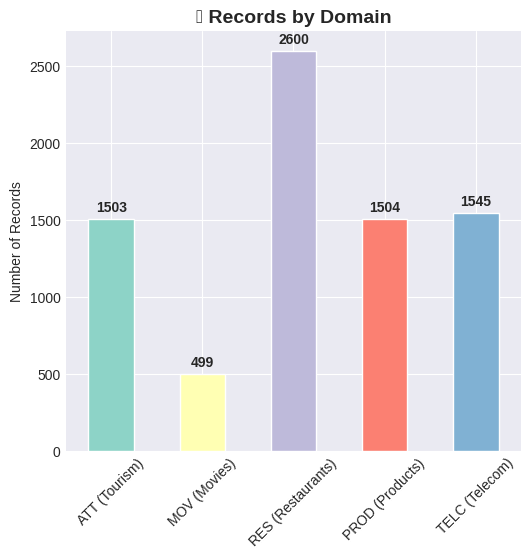

In [112]:
plt.style.use('seaborn-v0_8-darkgrid')
fig = plt.figure(figsize=(20, 12))
ax1 = plt.subplot(2, 3, 1)
domain_counts = pd.Series({k: len(v) for k, v in datasets.items()})
colors = plt.cm.Set3(range(len(domain_counts)))
domain_counts.plot(kind='bar', ax=ax1, color=colors)
ax1.set_title('📊 Records by Domain', fontsize=14, fontweight='bold')
ax1.set_ylabel('Number of Records')
ax1.tick_params(axis='x', rotation=45)
for i, v in enumerate(domain_counts.values):
    ax1.text(i, v + 50, str(v), ha='center', fontweight='bold')

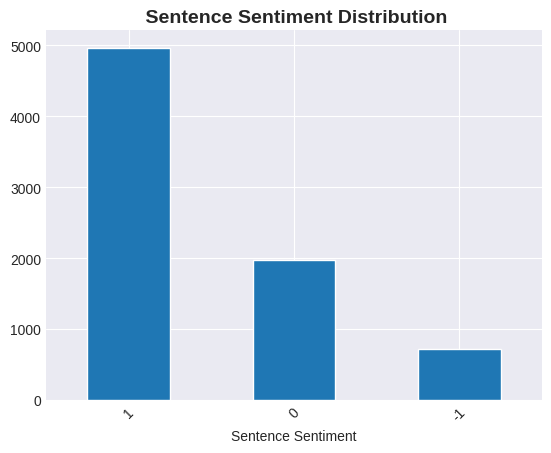

In [144]:
ax2 = plt.subplot(1, 1, 1)
cols_all = identify_columns(df_all)
sentiment_col = cols_all['sentiment']
if sentiment_col:
    sentiment_dist = df_all[sentiment_col].value_counts()
    bar_colors = ['#d62728' if x == 'negative' else '#2ca02c' if x == 'positive' else '#1f77b4'
                  for x in sentiment_dist.index]
    sentiment_dist.plot(kind='bar', ax=ax2, color=bar_colors)
    ax2.set_title(f' {sentiment_col} Distribution', fontsize=14, fontweight='bold')
    ax2.tick_params(axis='x', rotation=45)

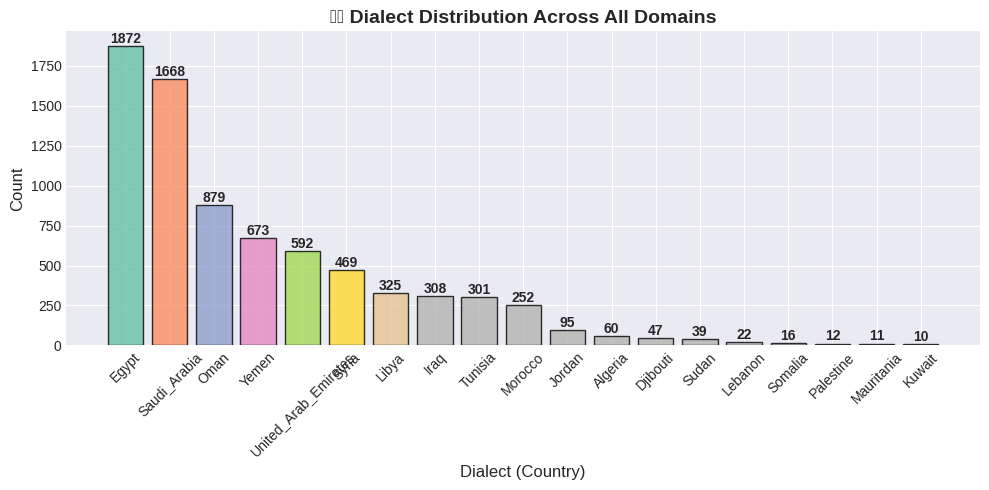

In [142]:
fig, ax = plt.subplots(figsize=(10, 5))
dialect_counts = df_all['dialect'].value_counts()
colors = plt.cm.Set2(range(len(dialect_counts)))
bars = ax.bar(dialect_counts.index, dialect_counts.values, color=colors, edgecolor='black', alpha=0.8)
ax.set_title(' Dialect Distribution Across All Domains', fontsize=14, fontweight='bold')
ax.set_xlabel('Dialect (Country)', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.tick_params(axis='x', rotation=45)
for bar, val in zip(bars, dialect_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            str(val), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

**Note:**

The dataset exhibits an imbalance in sentiment classes, with certain classes appearing significantly more frequently.

This imbalance can bias models toward dominant classes, necessitating the use of balancing techniques.

Text(0.5, 28.383333333333326, 'Sentiment')

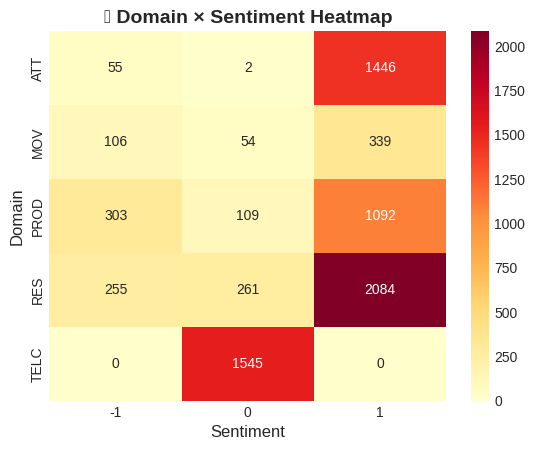

In [140]:
ax5 = plt.subplot(1, 1, 1)

# Build domain column from datasets since there's no single 'Domain' column
domain_labels = (
    ['ATT'] * len(ATTdf) +
    ['MOV'] * len(MOVdf) +
    ['RES'] * len(RESdf) +
    ['PROD'] * len(PRODdf) +
    ['TELC'] * len(TELCdf)
)
df_all['Domain'] = domain_labels

sentiment_col = 'Sentence Sentiment'

domain_sentiment = pd.crosstab(df_all['Domain'], df_all[sentiment_col])
sns.heatmap(domain_sentiment, annot=True, fmt='d', cmap='YlOrRd', ax=ax5)
ax5.set_title('🔥 Domain × Sentiment Heatmap', fontsize=14, fontweight='bold')
ax5.set_ylabel('Domain', fontsize=12)
ax5.set_xlabel('Sentiment', fontsize=12)

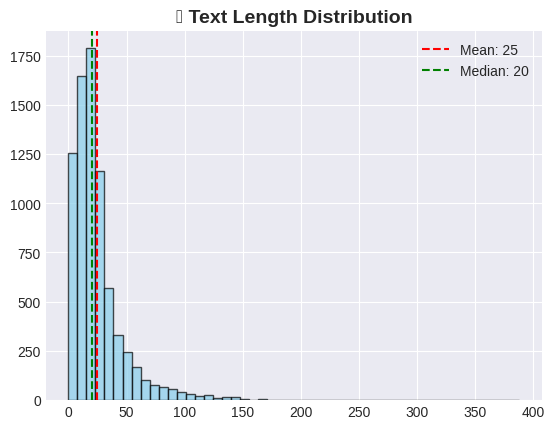

In [126]:
ax3 = plt.subplot(1, 1, 1)
text_col = cols_all['text'] or 'Sentences'
text_lengths = df_all[text_col].str.len().dropna()
ax3.hist(text_lengths, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
ax3.set_title('📏 Text Length Distribution', fontsize=14, fontweight='bold')
ax3.axvline(text_lengths.mean(), color='red', linestyle='--', label=f'Mean: {text_lengths.mean():.0f}')
ax3.axvline(text_lengths.median(), color='green', linestyle='--', label=f'Median: {text_lengths.median():.0f}')
ax3.legend()

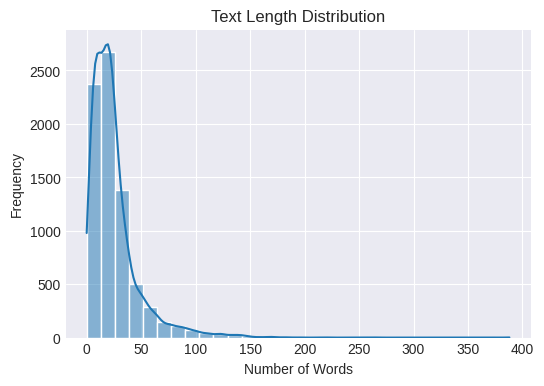

In [155]:
df_all['text_length'] = df_all['Sentences'].apply(lambda x: len(x) if isinstance(x, list) else 0)

plt.figure(figsize=(6,4))
sns.histplot(df_all['text_length'], bins=30, kde=True)
plt.title("Text Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

**Note:**

The text length distribution shows that most samples are relatively short, which is typical for user-generated content.

This has implications for model selection, as shorter texts may limit contextual information for sentiment and aspect detection.

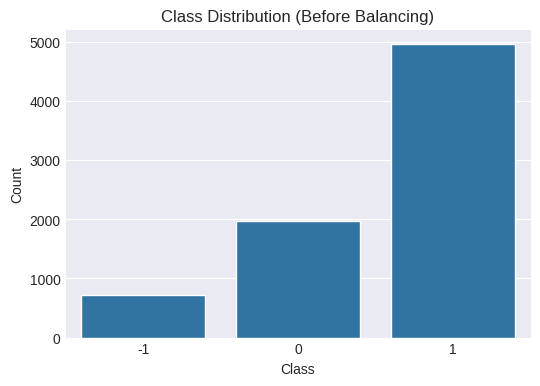

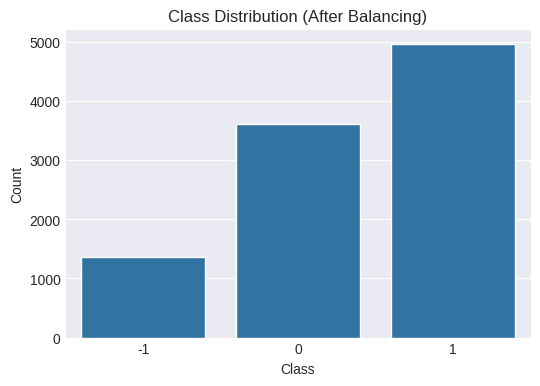

In [148]:
def plot_class_distribution(y, title):
    plt.figure(figsize=(6,4))
    sns.countplot(x=y)
    plt.title(title)
    plt.xlabel("Class")
    plt.ylabel("Count")
    plt.show()

# BEFORE
plot_class_distribution(df_all['Sentence Sentiment'], "Class Distribution (Before Balancing)")

# Apply balancing (example: oversampling)
from sklearn.utils import resample

df_majority = df_all[df_all['Sentence Sentiment'] == df_all['Sentence Sentiment'].value_counts().idxmax()]
df_minority = df_all[df_all['Sentence Sentiment'] != df_all['Sentence Sentiment'].value_counts().idxmax()]

df_minority_upsampled = resample(df_minority,
                                replace=True,
                                n_samples=len(df_majority),
                                random_state=42)

df_balanced = pd.concat([df_majority, df_minority_upsampled])

# AFTER
plot_class_distribution(df_balanced['Sentence Sentiment'], "Class Distribution (After Balancing)")

**Note:**

Before balancing, the dataset shows a clear class imbalance, where one sentiment class dominates the distribution.

After applying oversampling, the class distribution becomes more uniform, reducing bias and improving the model’s ability to generalize across all sentiment classes.

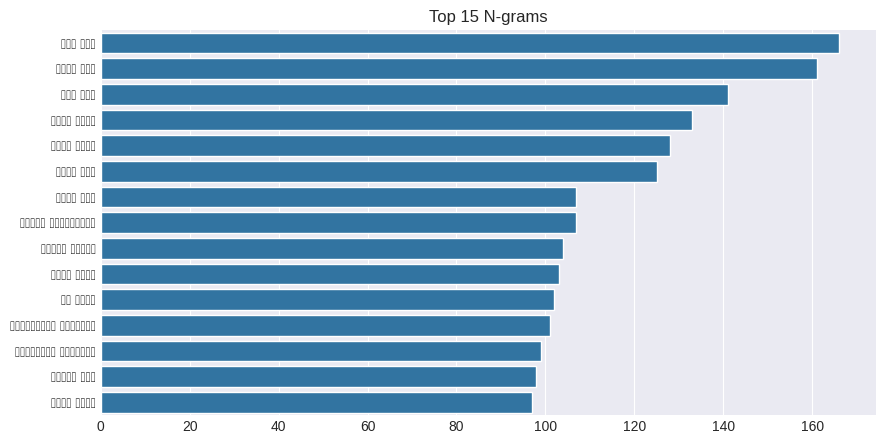

In [151]:
from sklearn.feature_extraction.text import CountVectorizer

def plot_top_ngrams(corpus, n=20, ngram_range=(2,2)):
    # Join list of tokens into a single string for CountVectorizer
    corpus_str = [" ".join(tokens) for tokens in corpus]

    vec = CountVectorizer(ngram_range=ngram_range, analyzer='word')
    X = vec.fit_transform(corpus_str)

    sum_words = X.sum(axis=0)
    words_freq = [(word, sum_words[0, idx])
                  for word, idx in vec.vocabulary_.items()]

    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)[:n]

    words = [w[0] for w in words_freq]
    counts = [w[1] for w in words_freq]

    plt.figure(figsize=(10,5))
    sns.barplot(x=counts, y=words)
    plt.title(f"Top {n} N-grams")
    plt.show()

# Example
plot_top_ngrams(df_all['Sentences'], n=15, ngram_range=(2,2))  # bigrams

**Note:**

The most frequent n-grams highlight common contextual patterns in the dataset.
These phrases often reflect domain-specific expressions and sentiment indicators, making them useful for downstream tasks like aspect extraction and sentiment classification.

✓ EDA overview saved as 'EDA_overview.png'


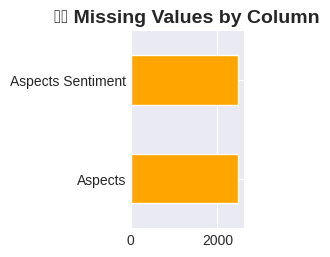

In [129]:
# 6. Missing values
ax6 = plt.subplot(2, 3, 6)
missing_data = df_all.isnull().sum()
missing_data = missing_data[missing_data > 0]
if len(missing_data) > 0:
    missing_data.plot(kind='barh', ax=ax6, color='orange')
    ax6.set_title('⚠️ Missing Values by Column', fontsize=14, fontweight='bold')
else:
    ax6.text(0.5, 0.5, 'No Missing Values Found! ✓', ha='center', va='center', fontsize=14, fontweight='bold')
    ax6.set_title('⚠️ Missing Values', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('EDA_overview.png', dpi=300, bbox_inches='tight')
print("✓ EDA overview saved as 'EDA_overview.png'")
plt.show()


DETAILED ASPECT ANALYSIS

✓ Aspect column: 'Aspects'

📊 Total Unique Aspects: 4240

Top 20 Most Common Aspects:
   1. خدمه:   100 (1.31%)
   2. السلعه:    65 (0.85%)
   3. المنتج:    56 (0.73%)
   4. منتج:    46 (0.60%)
   5. سعر:    40 (0.52%)
   6. سلعه:    38 (0.50%)
   7. مكان:    36 (0.47%)
   8. جهاز:    18 (0.24%)
   9. الجهاز:    17 (0.22%)
  10. العطر:    16 (0.21%)
  11. السعر:    16 (0.21%)
  12. عطر:    14 (0.18%)
  13. المكان:    14 (0.18%)
  14. مطعم:    12 (0.16%)
  15. فيلم:    12 (0.16%)
  16. خدمه العملاء:    11 (0.14%)
  17. شكل:    11 (0.14%)
  18. الوايفاي:     9 (0.12%)
  19. جوده:     9 (0.12%)
  20. المنتجات:     9 (0.12%)

✓ Aspect analysis saved as 'Aspect_analysis.png'


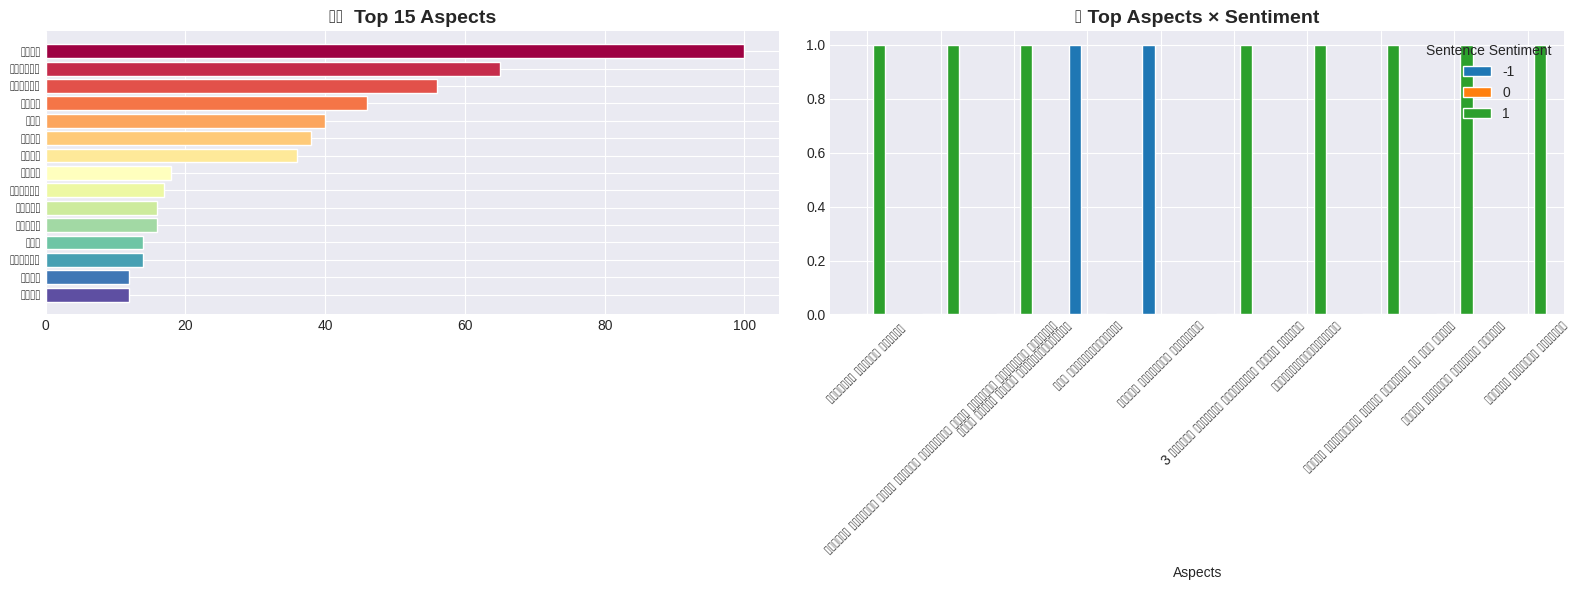

In [130]:
print("\n" + "="*100)
print("DETAILED ASPECT ANALYSIS")
print("="*100)

cols_all = identify_columns(df_all)
aspect_col = cols_all['aspect']

if aspect_col:
    print(f"\n✓ Aspect column: '{aspect_col}'")
    print(f"\n📊 Total Unique Aspects: {df_all[aspect_col].nunique()}")
    print("\nTop 20 Most Common Aspects:")
    aspect_counts = df_all[aspect_col].value_counts().head(20)
    for i, (aspect, count) in enumerate(aspect_counts.items(), 1):
        pct = count / len(df_all) * 100
        print(f"  {i:2d}. {aspect}: {count:5d} ({pct:.2f}%)")

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    top15 = df_all[aspect_col].value_counts().head(15)
    axes[0].barh(range(len(top15)), top15.values,
                 color=plt.cm.Spectral(np.linspace(0, 1, len(top15))))
    axes[0].set_yticks(range(len(top15)))
    axes[0].set_yticklabels(top15.index)
    axes[0].set_title('🏷️  Top 15 Aspects', fontsize=14, fontweight='bold')
    axes[0].invert_yaxis()

    if sentiment_col:
        aspect_sentiment = pd.crosstab(df_all[aspect_col].head(2000), df_all[sentiment_col].head(2000))
        aspect_sentiment.head(10).plot(kind='bar', ax=axes[1])
        axes[1].set_title('🔀 Top Aspects × Sentiment', fontsize=14, fontweight='bold')
        axes[1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.savefig('Aspect_analysis.png', dpi=300, bbox_inches='tight')
    print("\n✓ Aspect analysis saved as 'Aspect_analysis.png'")
    plt.show()
else:
    print("\n⚠️  No aspect column detected. Skipping aspect analysis.")



VOCABULARY AND LINGUISTIC ANALYSIS

🔤 Building vocabulary (sample of 500 texts)...

✓ VOCABULARY STATISTICS:
  Unique tokens (vocab size)  : 6010
  Total tokens                : 14789
  Avg tokens / document       : 29.58
  Type-Token Ratio (TTR)      : 0.4064

✓ TOP 30 MOST FREQUENT TOKENS:
   1. علي             — 223 occurrences
   2. جدا             — 191 occurrences
   3. مكان            — 166 occurrences
   4. ان              — 152 occurrences
   5. راءع            — 138 occurrences
   6. الي             — 129 occurrences
   7. راءعه           — 101 occurrences
   8. المكان          — 96 occurrences
   9. جميله           — 88 occurrences
  10. جميل            — 76 occurrences
  11. اجمل            — 65 occurrences
  12. او              — 60 occurrences
  13. اكثر            — 60 occurrences
  14. رحله            — 51 occurrences
  15. مصر             — 51 occurrences
  16. شرم             — 51 occurrences
  17. المتحف          — 45 occurrences
  18. كانت            — 42 occurrenc

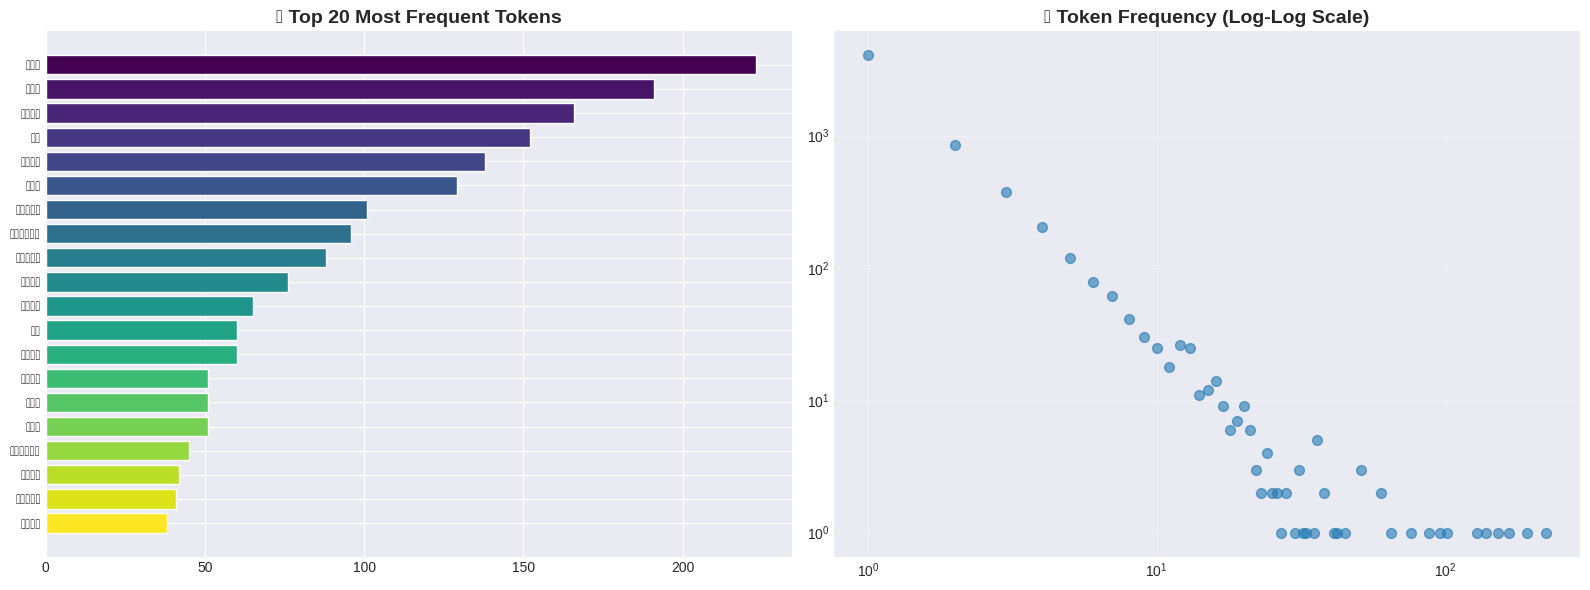

In [133]:
print("\n" + "="*100)
print("VOCABULARY AND LINGUISTIC ANALYSIS")
print("="*100)

text_col = cols_all['text'] or 'Sentences'
vocabulary   = set()
all_tokens   = []
all_pre_texts = []

print("\n🔤 Building vocabulary (sample of 500 texts)...")
for text in df_all[text_col].dropna().head(500):
    tokens =normalize_arabic_text(text)
    all_tokens.extend(tokens)
    all_pre_texts.append(tokens)
    vocabulary.update(tokens)

print(f"\n✓ VOCABULARY STATISTICS:")
print(f"  Unique tokens (vocab size)  : {len(vocabulary)}")
print(f"  Total tokens                : {len(all_tokens)}")
print(f"  Avg tokens / document       : {len(all_tokens) / len(all_pre_texts):.2f}")
print(f"  Type-Token Ratio (TTR)      : {len(vocabulary) / len(all_tokens):.4f}")

token_freq = Counter(all_tokens)
print(f"\n✓ TOP 30 MOST FREQUENT TOKENS:")
for i, (tok, freq) in enumerate(token_freq.most_common(30), 1):
    print(f"  {i:2d}. {tok:15s} — {freq} occurrences")

hapax = [w for w, f in token_freq.items() if f == 1]
print(f"\n✓ HAPAX LEGOMENA (words appearing once): {len(hapax)} ({len(hapax)/len(vocabulary)*100:.2f}%)")
print(f"  Examples: {', '.join(list(hapax)[:20])}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
top_tokens = dict(token_freq.most_common(20))
axes[0].barh(range(len(top_tokens)), list(top_tokens.values()),
             color=plt.cm.viridis(np.linspace(0, 1, len(top_tokens))))
axes[0].set_yticks(range(len(top_tokens)))
axes[0].set_yticklabels(list(top_tokens.keys()))
axes[0].set_title('🔤 Top 20 Most Frequent Tokens', fontsize=14, fontweight='bold')
axes[0].invert_yaxis()

freq_counts = sorted(Counter(token_freq.values()).items())
axes[1].scatter([f[0] for f in freq_counts], [f[1] for f in freq_counts], alpha=0.6, s=50)
axes[1].set_xscale('log'); axes[1].set_yscale('log')
axes[1].set_title('📊 Token Frequency (Log-Log Scale)', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('Vocabulary_analysis.png', dpi=300, bbox_inches='tight')
print("\n✓ Vocabulary analysis saved as 'Vocabulary_analysis.png'")
plt.show()


**Result:**

The analysis highlights key challenges in Arabic text processing, including class imbalance, short text length, and noisy user-generated content.

Preprocessing significantly improves text quality, while visualization reveals important linguistic and statistical patterns that guide downstream modeling.

## Pipeline